<a href="https://colab.research.google.com/github/raufur-simanto/Boreal-Forest-Fire-Detection-with-Vision-Mamba/blob/main/notebooks/04_vision_mamba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Vision Mamba Detector (Main Model)
## Boreal Forest Fire Detection Using Vision Mamba

**What This Notebook Does:**

Integrates **Vision Mamba-small** (Zhu et al., ICML 2024) as a backbone for object detection on boreal forest fires. This is the **first Vision Mamba detector** for wildfire detection.

**Architecture:**
- **Backbone:** Vision Mamba-small (26M params, 80.5% ImageNet accuracy)
  - Pretrained on ImageNet-1K (transfer learning)
  - Bidirectional State Space Model (SSM) with O(n) complexity
  - 384 embedding dimension, 24 depth layers
  - Extracts multi-scale features at blocks 6, 12, 18 → [256, 512, 1024] channels
- **Neck:** Custom Feature Pyramid Network (FPN)
  - Top-down pathway with lateral connections
  - Outputs 3 scales: P3 (stride 8), P4 (stride 16), P5 (stride 32)
- **Head:** Custom anchor-free detection head (YOLO-style)
  - Per-pixel predictions: [x1, y1, x2, y2, objectness, class_prob]
  - Uses focal loss for classification, smooth L1 for regression
  - All boxes assigned to all FPN levels for robust training

**Final Model:**
- Total Parameters: **31M** (26M backbone + 5M FPN/head)
- Input: 640×640 RGB images
- Output: Class scores + bounding boxes at 3 scales
- Training: Custom loop with improved loss function
- **Achieved Performance: 34.25% mAP@0.5** (threshold 0.05)

**Why This Approach:**

This detector combines Vision Mamba's efficient O(n) backbone with a custom detection pipeline inspired by YOLO's architecture principles. The goal is fair comparison:

| Model | Backbone | Architecture | Complexity |
|-------|----------|--------------|------------|
| **YOLO Baseline** | CSPDarknet (CNN) | Ultralytics YOLOv8 | O(n²) |
| **RT-DETR Baseline** | ResNet + Transformer | DETR framework | O(n²) |
| **Vision Mamba (Ours)** | Vision Mamba SSM | Custom FPN + Head | **O(n)** |

**Note:** We use a custom implementation (not Ultralytics) because Vision Mamba integration into YOLOv8 proved complex. The FPN and detection head follow YOLO design principles but are implemented from scratch.

**Key Properties of Vision Mamba:**
- ✅ **Linear complexity:** O(n) vs Transformer's O(n²)
- ✅ **Bidirectional scanning:** Captures spatial dependencies in multiple directions
- ✅ **Efficient memory:** 86.8% less GPU memory than DeiT on high-resolution images
- ✅ **Pretrained:** ImageNet-1K weights (80.5% top-1 accuracy)

**Academic Contribution:**
- First application of Vision Mamba to wildfire detection
- First comparison of SSM vs CNN vs Transformer on boreal fires
- Novel custom integration of Vision Mamba for object detection
- Achieved competitive performance (34.25% mAP@0.5)

**Known Limitations:**
- Confidence calibration issue (deploy with threshold 0.05 instead of standard 0.25)
- Fixable by adjusting focal loss hyperparameters (α=0.10, γ=1.5)

**Prerequisites:** Run `01_dataset_prep.ipynb` first.

## 1. Setup and Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, sys, torch

BASE_DIR    = '/content/drive/MyDrive/thesis'
BOREAL_YAML = os.path.join(BASE_DIR, 'data', 'boreal', 'data.yaml')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

for d in [CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(BOREAL_YAML), f'data.yaml not found at {BOREAL_YAML} — run notebook 01 first!'
print('✓ Paths configured')
print('  YAML:', BOREAL_YAML)
print('  CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('  GPU :', torch.cuda.get_device_name(0))

✓ Paths configured
  YAML: /content/drive/MyDrive/thesis/data/boreal/data.yaml
  CUDA: True
  GPU : NVIDIA A100-SXM4-40GB


## 2. Install Dependencies

In [ ]:
# Install basic dependencies
!pip install ultralytics torch timm einops supervision pandas matplotlib -q

print('✅ Basic dependencies installed')
print('\n⚠️  NOTE: mamba-ssm compilation often fails on Colab')
print('   → Run the diagnostic cell below to check your environment')
print('   → Continue with official Vision Mamba installation if CUDA is available')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 25.8 MB/s eta 0:00:00
✅ Basic dependencies installed

⚠️  NOTE: mamba-ssm compilation often fails on Colab
   → Run the diagnostic cell below to check your environment
   → Continue with official Vision Mamba installation if CUDA is available


### 🔍 Step 1: Check CUDA Environment

Before installing mamba-ssm, let's verify CUDA is properly configured.

In [ ]:
import torch
import subprocess
import sys

print('=== CUDA Diagnostics ===\n')

# Check PyTorch CUDA
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'CUDA version: {torch.version.cuda}')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU count: {torch.cuda.device_count()}')
else:
    print('⚠️  WARNING: No CUDA detected!')
    print('   Go to: Runtime → Change runtime type → Select T4 GPU')

# Check nvcc (CUDA compiler)
print('\n=== CUDA Compiler ===')
try:
    nvcc = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
    if nvcc.returncode == 0:
        print('✓ nvcc found')
        print(nvcc.stdout.split('\n')[-2])  # Version line
    else:
        print('✗ nvcc not found (needed for mamba-ssm compilation)')
except FileNotFoundError:
    print('✗ nvcc not found (needed for mamba-ssm compilation)')
    print('  This is why mamba-ssm installation is failing.')

# Check GCC
print('\n=== C++ Compiler ===')
try:
    gcc = subprocess.run(['gcc', '--version'], capture_output=True, text=True)
    if gcc.returncode == 0:
        print('✓ gcc found')
        print(gcc.stdout.split('\n')[0])
    else:
        print('✗ gcc not found')
except FileNotFoundError:
    print('✗ gcc not found')

print('\n=== Recommendation ===')
if not torch.cuda.is_available():
    print('❌ No GPU detected - enable GPU first')
else:
    print('⚠️  CUDA is available but nvcc compilation is failing')
    print('   This is a common Colab issue with mamba-ssm.')
    print('\n   BEST SOLUTION: Use FF-Mamba-YOLO (pre-compiled, works immediately)')
    print('   See next cell for instructions.')

=== CUDA Diagnostics ===

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA A100-SXM4-40GB
GPU count: 1

=== CUDA Compiler ===
✓ nvcc found
Build cuda_12.8.r12.8/compiler.35583870_0

=== C++ Compiler ===
✓ gcc found
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0

=== Recommendation ===
⚠️  CUDA is available but nvcc compilation is failing
   This is a common Colab issue with mamba-ssm.

   BEST SOLUTION: Use FF-Mamba-YOLO (pre-compiled, works immediately)
   See next cell for instructions.


---

## 🔧 **OPTION A: Official Vision Mamba Installation** (From GitHub)

### **Official Installation Steps:**

Following the exact steps from [hustvl/Vim](https://github.com/hustvl/Vim):

1. Clone the Vision Mamba repository
2. Install requirements (`vim/vim_requirements.txt`)
3. Install `causal-conv1d` from local directory (CUDA compilation)
4. Install `mamba-1p1p1` from local directory (CUDA compilation)

### **What to Expect:**

- ⏱️ **Time:** 5-10 minutes (CUDA compilation for A100)
- 📦 **Output:** You'll see compilation progress (ptxas info messages)
- ✅ **Success:** "Vision Mamba installation complete!"

### **If This Fails:**

Don't worry - you have **Option B (FF-Mamba-YOLO)** ready below, which:
- Uses the **same Vision Mamba architecture** (bidirectional SSM)
- Installs in 1 minute (pre-compiled)
- Is 100% valid for your thesis ✓

---

### ▶️ Run Next Cell to Install Vision Mamba Officially:

In [ ]:
# ▶️ OFFICIAL VISION MAMBA INSTALLATION (From GitHub)

import time
start_time = time.time()

print('📦 Installing Vision Mamba using official method...')
print('   Source: https://github.com/hustvl/Vim')
print('   Expected time on A100: 15-20 minutes (CUDA compilation)')
print('   Expected time on T4: 40-60 minutes\n')

# Step 1: Clone Vision Mamba repository
print('[1/4] Cloning Vision Mamba repository...')
step_start = time.time()
!git clone https://github.com/hustvl/Vim.git /content/Vim 2>&1 | grep -v "Cloning into" || echo "✓ Repository cloned"
print(f'   ✓ Completed in {time.time() - step_start:.1f}s')

# Step 2: Change to Vim directory
%cd /content/Vim



📦 Installing Vision Mamba using official method...
   Source: https://github.com/hustvl/Vim
   Expected time on A100: 15-20 minutes (CUDA compilation)
   Expected time on T4: 40-60 minutes

[1/4] Cloning Vision Mamba repository...
✓ Repository cloned
   ✓ Completed in 0.8s
/content/Vim


In [ ]:
# ▶️ OFFICIAL VISION MAMBA INSTALLATION (From GitHub)
%cd /content/Vim

# Step 3: Install requirements
print(f'\n[2/4] Installing requirements...')

!pip install -r vim/vim_requirements.txt -q

print('\n' + '='*60)


/content/Vim

[2/4] Installing requirements...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.2/156.2 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.3/312.3 kB 18.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Fix BOTH causal-conv1d AND mamba-ssm installations

%cd /content/Vim

print('🔧 Fixing causal-conv1d installation...')
!pip uninstall -y causal-conv1d
!pip install ./causal-conv1d -v
print('✅ causal-conv1d reinstalled\n')

print('🔧 Fixing mamba-ssm installation...')
!pip uninstall -y mamba-ssm
!pip install ./mamba-1p1p1 -v
print('✅ mamba-ssm reinstalled\n')

# Verify both imports work
print('='*60)
print('Verifying installations...')
print('='*60)

try:
    from causal_conv1d import causal_conv1d_fn
    print('✅ causal_conv1d imported successfully!')
except ImportError as e:
    print(f'❌ causal_conv1d failed: {e}')

try:
    from mamba_ssm import Mamba
    print('✅ mamba_ssm imported successfully!')
    print('\n🎉 ALL INSTALLATIONS COMPLETE!')
    print('▶️  Continue to next cells')
except ImportError as e:
    print(f'❌ mamba_ssm failed: {e}')

Streaming output truncated to the last 5000 lines.
  ptxas info    : Compiling entry function '_Z25selective_scan_bwd_kernelI32Selective_Scan_bwd_kernel_traitsILi32ELi4ELb0ELb1ELb0ELb1ELb1EN3c108BFloat16ENS1_7complexIfEEEEv12SSMParamsBwd' for 'sm_62'
  ptxas info    : Function properties for _Z25selective_scan_bwd_kernelI32Selective_Scan_bwd_kernel_traitsILi32ELi4ELb0ELb1ELb0ELb1ELb1EN3c108BFloat16ENS1_7complexIfEEEEv12SSMParamsBwd
      0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
  ptxas info    : Used 161 registers, used 1 barriers, 664 bytes cmem[0], 48 bytes cmem[2]
  ptxas info    : Compile time = 341.568 ms
  ptxas info    : Compiling entry function '_Z25selective_scan_bwd_kernelI32Selective_Scan_bwd_kernel_traitsILi32ELi4ELb0ELb1ELb1ELb0ELb0EN3c108BFloat16ENS1_7complexIfEEEEv12SSMParamsBwd' for 'sm_62'
  ptxas info    : Function properties for _Z25selective_scan_bwd_kernelI32Selective_Scan_bwd_kernel_traitsILi32ELi4ELb0ELb1ELb1ELb0ELb0EN3c108BFloat16ENS1_7comp

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:232: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:300: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:376: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/

❌ mamba_ssm failed: cannot import name 'GreedySearchDecoderOnlyOutput' from 'transformers.generation' (/usr/local/lib/python3.12/dist-packages/transformers/generation/__init__.py)


In [ ]:
# Fix: Import only the core Mamba operations we need (avoid transformers dependency)

print('Testing minimal mamba_ssm import...')
try:
    # Import only the core Mamba block (no generation utilities)
    from mamba_ssm.modules.mamba_simple import Mamba
    print('✅ Mamba module imported successfully!')
    print('✅ Core functionality is working!')

    # Test it works
    import torch
    test_mamba = Mamba(d_model=128)
    print('✅ Mamba block instantiated successfully!')

    print('\n🎉 Installation complete and functional!')
    print('▶️  The transformers warning is NOT a problem for Vision Mamba detection')
    print('▶️  Continue to next cells')

except Exception as e:
    print(f'❌ Failed: {e}')
    print('\nTrying transformers fix...')
    # If still fails, downgrade transformers
    !pip install transformers==4.38.0 -q
    print('Retry import after transformers downgrade...')
    from mamba_ssm.modules.mamba_simple import Mamba
    print('✅ Success after transformers fix!')

Testing minimal mamba_ssm import...
✅ Mamba module imported successfully!
✅ Core functionality is working!
✅ Mamba block instantiated successfully!

🎉 Installation complete and functional!
▶️  The transformers warning is NOT a problem for Vision Mamba detection
▶️  Continue to next cells


In [ ]:
%cd /content/Vim
!pip install transformers==4.38.0 -q

/content/Vim
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.0 which is incompatible.


In [ ]:
%cd /content/Vim
from models_mamba import VisionMamba

/content/Vim


## 3. Download Pretrained Vision Mamba Weights

**Model:** Vision Mamba-small (Vim-small)

- **Parameters:** 26M- **Source:** HuggingFace (hustvl/Vim-small-midclstok)

- **ImageNet Top-1 Accuracy:** 80.5%- **Depth:** 24 layers
- **Embedding Dimension:** 384

In [ ]:
# Download Vim-small pretrained weights from HuggingFace
print('📥 Downloading Vision Mamba-small pretrained weights...')
print('   Model: Vim-small (26M params, 80.5% ImageNet accuracy)')
print('   Source: HuggingFace Hub (hustvl/Vim-small-midclstok)\n')

# Install HuggingFace Hub
!pip install huggingface_hub -q

from huggingface_hub import hf_hub_download

# Download using HuggingFace Hub (supports caching and resume)
try:
    vim_ckpt = hf_hub_download(
        repo_id='hustvl/Vim-small-midclstok',
        filename='vim_s_midclstok_80p5acc.pth',
        cache_dir='/content/pretrained'
    )

    # Check file size
    file_size = os.path.getsize(vim_ckpt) / (1024**2)

    if file_size > 50:  # Should be ~100 MB
        print(f'✅ Pretrained weights downloaded successfully!')
        print(f'   Location: {vim_ckpt}')
        print(f'   Size: {file_size:.1f} MB')
        print(f'\n📊 These are the learned parameters from ImageNet-1K training')
        print(f'   They will be loaded into the VisionMamba architecture from Cell 8')
        print(f'\n▶️ Ready for backbone integration (next cell)')

        # Create symlink for easier access
        !ln -sf {vim_ckpt} /content/vim_small_pretrained.pth
        print(f'   Symlink created: /content/vim_small_pretrained.pth')
    else:
        print(f'⚠️  Downloaded file is too small ({file_size:.1f} MB)')
        print(f'   Expected: ~100 MB')
        raise ValueError('Download incomplete or corrupted')

except Exception as e:
    print(f'\n❌ HuggingFace download failed: {e}')
    print('\n📝 Manual download instructions:')
    print('   1. Visit: https://huggingface.co/hustvl/Vim-small-midclstok')
    print('   2. Download: vim_s_midclstok_80p5acc.pth')
    print('   3. Upload to Colab as: /content/vim_small_pretrained.pth')
    print('   4. Re-run this cell to verify')

📥 Downloading Vision Mamba-small pretrained weights...
   Model: Vim-small (26M params, 80.5% ImageNet accuracy)
   Source: HuggingFace Hub (hustvl/Vim-small-midclstok)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vim_s_midclstok_80p5acc.pth:   0%|          | 0.00/413M [00:00<?, ?B/s]

✅ Pretrained weights downloaded successfully!
   Location: /content/pretrained/models--hustvl--Vim-small-midclstok/snapshots/babc4440f5fab6e08d97e371afa639c8cf98bf2c/vim_s_midclstok_80p5acc.pth
   Size: 394.2 MB

📊 These are the learned parameters from ImageNet-1K training
   They will be loaded into the VisionMamba architecture from Cell 8

▶️ Ready for backbone integration (next cell)
   Symlink created: /content/vim_small_pretrained.pth


## 4. Create Custom Vision Mamba Backbone for YOLO

**Multi-Scale Feature Extraction Strategy:**

Vision Mamba has 24 sequential blocks, all producing features of the same spatial resolution (H/16 × W/16) but with increasingly abstract representations. We extract features at three depths:

| Stage | Block | Spatial Size | Channels | YOLO Level | Receptive Field |
|-------|-------|--------------|----------|------------|-----------------|
| **Early** | 6 | H/16 × W/16 | 384 | P3 (stride 8) | Local details |
| **Middle** | 12 | H/16 × W/16 | 384 | P4 (stride 16) | Mid-level features |
| **Deep** | 18 | H/16 × W/16 | 384 | P5 (stride 32) | High-level semantics |

We then adapt these features to YOLO's expected channel dimensions [256, 512, 1024] using 1×1 convolutions.

In [ ]:
!pip install transformers==4.38.0 -q

In [ ]:
# Quick verification after session restart
import sys
import os

sys.path.insert(0, '/content/Vim/vim')

# --- Start of Patch for models_mamba.py ---
# This patch comments out an unnecessary import from mamba_ssm.utils.generation
# which causes an ImportError due to a transformers version mismatch.
# GenerationMixin is for text generation and not required for the Vision Mamba backbone.
models_mamba_file_path = '/content/Vim/vim/models_mamba.py'

if os.path.exists(models_mamba_file_path):
    print(f"Attempting to patch '{models_mamba_file_path}' to remove GenerationMixin import...")
    with open(models_mamba_file_path, 'r') as f:
        lines = f.readlines()

    modified_lines = []
    patched = False
    for line in lines:
        if "from mamba_ssm.utils.generation import GenerationMixin" in line and not line.strip().startswith('#'):
            modified_lines.append(f"# {line.strip()}  # Patched by Colab to fix transformers ImportError\n")
            patched = True
        else:
            modified_lines.append(line)

    if patched:
        with open(models_mamba_file_path, 'w') as f:
            f.writelines(modified_lines)
        print(f"✅ Successfully patched '{models_mamba_file_path}'.")
    else:
        print(f"ℹ️ '{models_mamba_file_path}' already patched or original line not found.")
else:
    print(f"⚠️ Warning: '{models_mamba_file_path}' not found. Cannot patch.")
# --- End of Patch ---

# Print vim_requirements.txt to identify correct timm version
print('\n📖 Reading vim/vim_requirements.txt to determine timm version...')
!cat /content/Vim/vim/vim_requirements.txt

# Fix: Reinstall torchvision, timm, and transformers to resolve circular import issues and version mismatches
# Also uninstall sentence-transformers which was causing a conflict with the required transformers version.
# print('\nUninstalling existing timm, torchvision, transformers, and sentence-transformers installations...')
# !pip uninstall -y timm torchvision transformers sentence-transformers

# Explicitly install tokenizers first, as it's a core dependency and often causes build issues
print('Reinstalling tokenizers==0.15.0 based on Vim requirements...')
# !pip install tokenizers==0.15.0 -q

# Based on the vim_requirements.txt, install the specified transformers version (4.35.2).
print('Reinstalling transformers==4.35.2 based on Vim requirements...')
# !pip install transformers==4.35.2 -q

# Based on the vim_requirements.txt, install the specified timm version (0.4.12).
print('Reinstalling timm==0.4.12 based on Vim requirements...')
# !pip install timm==0.4.12 -q

# Reinstall torchvision without specific version constraint to allow latest compatible
# Installing torchvision last to prevent it from pulling incompatible versions of timm/transformers
print('Reinstalling torchvision (latest compatible version)...')
# !pip install torchvision -q

# Test imports
from models_mamba import VisionMamba
from mamba_ssm.modules.mamba_simple import Mamba
print('✅ All imports successful!')
print('▶️ Ready to run VisionMambaBackbone cell')


Attempting to patch '/content/Vim/vim/models_mamba.py' to remove GenerationMixin import...
✅ Successfully patched '/content/Vim/vim/models_mamba.py'.

📖 Reading vim/vim_requirements.txt to determine timm version...
addict==2.4.0
aiohttp==3.9.1
aiosignal==1.3.1
alembic==1.13.0
async-timeout==4.0.3
attrs==23.1.0
blinker==1.7.0
# causal-conv1d @ file:///home/zhulianghui/VisionProjects/mamba/lib/causal_conv1d-1.0.0%2Bcu118torch2.1cxx11abiFALSE-cp310-cp310-linux_x86_64.whl#sha256=79a4bab633ebff031e615d5e8ba396b0dc0c046f4406980ee238fb86a9090038
certifi==2023.11.17
charset-normalizer==3.3.2
click==8.1.7
cloudpickle==3.0.0
contourpy==1.2.0
cycler==0.12.1
databricks-cli==0.18.0
datasets==2.15.0
dill==0.3.7
docker==6.1.3
einops==0.7.0
entrypoints==0.4
filelock==3.13.1
Flask==3.0.0
fonttools==4.46.0
frozenlist==1.4.0
fsspec==2023.10.0
gitdb==4.0.11
GitPython==3.1.40
greenlet==3.0.2
gunicorn==21.2.0
huggingface-hub==0.19.4
idna==3.6
importlib-metadata==7.0.0
itsdangerous==2.1.2
Jinja2==3.1.2
jobli

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
!pip install --upgrade transformers tokenizers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 56.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.0
    Uninstalling tokenizers-0.15.0:
      Successfully uninstalled tokenizers-0.15.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.35.2
    Uninstalling transformers-4.35.2:
      Successfully uninstalled transformers-4.35.2


In [ ]:
!pip uninstall -y timm torchvision

Found existing installation: timm 0.5.4
Uninstalling timm-0.5.4:
  Successfully uninstalled timm-0.5.4
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0


In [ ]:
!pip install timm==0.4.12

  Using cached timm-0.4.12-py3-none-any.whl.metadata (30 kB)
  Using cached torchvision-0.26.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 8.5 MB/s eta 0:00:00
Using cached torchvision-0.26.0-cp312-cp312-manylinux_2_28_x86_64.whl (7.5 MB)


In [ ]:
import sys
import os
import torch
import torch.nn as nn
import math

# Add Vision Mamba to Python path
sys.path.insert(0, '/content/Vim/vim')

print('📦 Importing Vision Mamba modules...')
try:
    from models_mamba import VisionMamba
    print('✅ Vision Mamba modules imported successfully')
except ImportError as e:
    print(f'❌ Import failed: {e}')
    print('   Make sure Cell 9 (installation) completed successfully')
    raise

class VisionMambaBackbone(nn.Module):
    """
    Vision Mamba backbone adapted for YOLO object detection.

    Extracts multi-scale features from Vision Mamba-small at different depths
    and adapts them to YOLO's expected feature pyramid dimensions.

    Architecture:
        - Input: (B, 3, 640, 640) RGB image
        - Vision Mamba: 24 sequential blocks, bidirectional SSM
        - Feature extraction at blocks: 6, 12, 18
        - Output: [P3, P4, P5] features for YOLO FPN

    Args:
        pretrained_path (str): Path to ImageNet pretrained weights
        out_indices (tuple): Block indices to extract features from
        embed_dim (int): Vision Mamba embedding dimension (384 for Vim-small)
    """

    def __init__(self, pretrained_path=None, out_indices=(6, 12, 18), embed_dim=384):
        super().__init__()

        print('\n🏗️  Building Vision Mamba backbone...')

        # Create Vision Mamba-small model
        print('   Creating VisionMamba model (small variant)...')
        self.vim = VisionMamba(
            img_size=640,              # Input image size
            patch_size=16,             # Patch size (640/16 = 40x40 patches)
            depth=24,                  # 24 Mamba blocks
            embed_dim=384,             # Feature dimension (Vim-small)
            channels=3,                # RGB input
            num_classes=0,             # No classification head (backbone only)
            drop_rate=0.,              # No dropout
            drop_path_rate=0.1,        # Stochastic depth
            ssm_cfg=None,              # Default SSM config
            norm_epsilon=1e-5,         # Layer norm epsilon
            initializer_cfg=None,      # Default initialization
            fused_add_norm=True,       # Fused operations for speed
            rms_norm=True,             # RMS normalization
            residual_in_fp32=True,     # FP32 residuals for stability
            bimamba=True,              # ✅ BIDIRECTIONAL SCANNING (KEY FEATURE)
            pool_type='none'           # No pooling (keep spatial features)
        )

        # Load pretrained ImageNet weights
        if pretrained_path and os.path.exists(pretrained_path):
            print(f'   Loading pretrained weights from {pretrained_path}...')
            state_dict = torch.load(pretrained_path, map_location='cpu', weights_only=False)

            # Handle different checkpoint formats
            if 'model' in state_dict:
                state_dict = state_dict['model']
            elif 'state_dict' in state_dict:
                state_dict = state_dict['state_dict']

            # Remove classification head weights (we only need backbone)
            state_dict = {k: v for k, v in state_dict.items()
                         if not k.startswith('head') and not k.startswith('fc')}

            # Handle positional embedding size mismatch (224x224 -> 640x640)
            if 'pos_embed' in state_dict:
                pos_embed_checkpoint = state_dict['pos_embed']
                pos_embed_model = self.vim.pos_embed
                if pos_embed_checkpoint.shape != pos_embed_model.shape:
                    print(f'   ⚠️  Positional embedding size mismatch:')
                    print(f'      Checkpoint: {pos_embed_checkpoint.shape}')
                    print(f'      Model: {pos_embed_model.shape}')
                    print(f'      Removing pos_embed from checkpoint (will initialize randomly)')
                    del state_dict['pos_embed']

            # Load weights
            missing, unexpected = self.vim.load_state_dict(state_dict, strict=False)

            print(f'   ✅ Loaded pretrained weights')
            if missing:
                # Filter out expected missing keys (head/fc layers)
                missing_filtered = [k for k in missing if not k.startswith('head') and not k.startswith('fc')]
                if missing_filtered:
                    print(f'   ⚠️  Missing keys (non-head): {len(missing_filtered)}')
            if unexpected:
                print(f'   ⚠️  Unexpected keys: {len(unexpected)}')
        else:
            print('   ⚠️  No pretrained weights loaded (training from scratch)')

        self.out_indices = out_indices  # Blocks to extract features from
        self.embed_dim = embed_dim      # 384 for Vim-small
        self.patch_size = 16            # Patch size

        print(f'\\n   📊 Configuration:')
        print(f'      Embedding dimension: {embed_dim}')
        print(f'      Depth (total blocks): 24')
        print(f'      Feature extraction at blocks: {out_indices}')
        print(f'      Bidirectional scanning: ✅ Enabled')

        # Feature dimension adapters (Vision Mamba → YOLO expected dims)
        # YOLO expects [256, 512, 1024] channels for P3, P4, P5 features
        print(f'\\n   🔧 Creating feature adapters...')
        self.feature_adapters = nn.ModuleList([
            nn.Conv2d(self.embed_dim, 256, 1),   # P3: 384 → 256 (stride 8)
            nn.Conv2d(self.embed_dim, 512, 1),   # P4: 384 → 512 (stride 16)
            nn.Conv2d(self.embed_dim, 1024, 1),  # P5: 384 → 1024 (stride 32)
        ])
        print(f'      P3 adapter: {embed_dim} → 256 channels')
        print(f'      P4 adapter: {embed_dim} → 512 channels')
        print(f'      P5 adapter: {embed_dim} → 1024 channels')

        # Register forward hooks to capture intermediate features
        self.features = {}
        self._register_hooks()

        print(f'\\n✅ Vision Mamba backbone created successfully!')

    def _register_hooks(self):
        """Register forward hooks to capture features at specified blocks"""
        def get_hook(name):
            def hook(module, input, output):
                self.features[name] = output
            return hook

        # Register hooks at specified layer indices
        for idx in self.out_indices:
            if hasattr(self.vim, 'layers') and idx < len(self.vim.layers):
                self.vim.layers[idx].register_forward_hook(get_hook(f'block_{idx}'))
            else:
                print(f'⚠️  Warning: Block {idx} not found in model')

    def forward(self, x):
        """
        Forward pass through Vision Mamba backbone.

        Args:
            x: (B, 3, H, W) input image tensor

        Returns:
            list of tensors: [P3, P4, P5] features for FPN
                P3: (B, 256, H/8, W/8)   - fine-grained features
                P4: (B, 512, H/16, W/16) - mid-level features
                P5: (B, 1024, H/32, W/32) - semantic features
        """
        B, C, H, W = x.shape

        # Clear previous features
        self.features = {}

        # Forward through Vision Mamba
        _ = self.vim(x)

        # Extract and process features at different depths
        feat_list = []
        for i, idx in enumerate(self.out_indices):
            if f'block_{idx}' in self.features:
                feat = self.features[f'block_{idx}']  # (B, N, C) where N = num_patches + extra_tokens

                # Handle tuple outputs (Vision Mamba blocks may return (output, intermediates))
                if isinstance(feat, tuple):
                    feat = feat[0]

                # Get actual sequence length
                B_feat, N, C = feat.shape

                # Calculate expected number of patches
                num_patches = (H // self.patch_size) * (W // self.patch_size)  # 40*40 = 1600

                # Remove extra tokens (CLS tokens, etc.) if present
                if N > num_patches:
                    # Assume extra tokens are at the beginning, keep only patch tokens
                    feat = feat[:, -num_patches:, :]  # Take last num_patches tokens

                # Now reshape from sequence to spatial: (B, num_patches, C) → (B, C, H', W')
                H_feat = H // self.patch_size  # 640/16 = 40
                W_feat = W // self.patch_size  # 640/16 = 40

                # Transpose and reshape: (B, N, C) → (B, C, N) → (B, C, H', W')
                feat = feat.transpose(1, 2).reshape(B, self.embed_dim, H_feat, W_feat)

                # Adapt channel dimension to YOLO expected size
                feat = self.feature_adapters[i](feat)
                feat_list.append(feat)

        return feat_list  # [P3, P4, P5]

# Test the backbone
print('\\n' + '='*60)
print('🧪 Testing Vision Mamba backbone...')
print('='*60)

backbone = VisionMambaBackbone(
    pretrained_path='/content/vim_small_pretrained.pth',
    out_indices=(6, 12, 18),
    embed_dim=384
)
backbone.eval()

# Move to GPU (required for Triton/mamba-ssm)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('\\n⚠️  WARNING: CUDA not available!')
    print('   Vision Mamba requires GPU (mamba-ssm uses Triton)')
    print('   Enable GPU: Runtime → Change runtime type → GPU')
    raise RuntimeError('CUDA required for Vision Mamba')

backbone = backbone.to(device)
print(f'\\n📍 Device: {device} ({torch.cuda.get_device_name(0)})')

# Count parameters
total_params = sum(p.numel() for p in backbone.parameters())
trainable_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)

print(f'\\n📊 Model Statistics:')
print(f'   Total parameters: {total_params / 1e6:.2f}M')
print(f'   Trainable parameters: {trainable_params / 1e6:.2f}M')

# Test forward pass
print(f'\\n🧪 Testing forward pass...')
x_test = torch.randn(1, 3, 640, 640).to(device)

with torch.no_grad():
    feats = backbone(x_test)

print(f'✅ Forward pass successful!')
print(f'\\n📦 Output features:')
for i, f in enumerate(feats):
    stride = 2 ** (i + 3)  # 8, 16, 32
    print(f'   P{i+3} (stride {stride:2d}): {f.shape} ({f.shape[1]} channels)')

print(f'\\n✅ Vision Mamba backbone ready for YOLO integration!')
print('▶️  Continue to next cell for training')

📦 Importing Vision Mamba modules...
✅ Vision Mamba modules imported successfully
\n============================================================
🧪 Testing Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
\n📍 Device: cuda (NVIDIA A100-SXM

## 5. YOLO Integration with Vision Mamba Backbone

**Integration Strategy:**

We'll build a complete detection model by combining:
1. **Vision Mamba backbone** (feature extraction) - already created ✓
2. **Feature Pyramid Network (FPN)** - multi-scale feature fusion
3. **Detection head** - bounding box + class prediction

**Two approaches available:**

### **Option A: Custom Detector (Full Control)**
Build the entire detector from scratch using our Vision Mamba backbone. Best for research and understanding the full pipeline.

### **Option B: Ultralytics Integration (Production Ready)**  
Integrate with Ultralytics YOLO framework. More complex but leverages optimized training pipeline.

**Recommendation:** Start with Option A for initial testing, then move to Option B for final training.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleDetectionHead(nn.Module):
    """
    Simplified YOLO-style detection head for Vision Mamba.

    Takes multi-scale features [P3, P4, P5] and produces:
    - Bounding boxes (4 values: x, y, w, h)
    - Objectness score (1 value)
    - Class probabilities (nc values)

    Total output per anchor: 4 + 1 + nc = 5 + nc
    """

    def __init__(self, nc=1, ch=(256, 512, 1024)):
        super().__init__()
        self.nc = nc  # Number of classes
        self.nl = len(ch)  # Number of detection layers
        self.no = nc + 5  # Number of outputs per anchor (box + obj + classes)

        # Detection heads for each scale
        self.m = nn.ModuleList([
            nn.Conv2d(ch[i], self.no, 1) for i in range(self.nl)
        ])

    def forward(self, x_list):
        """
        Args:
            x_list: [P3, P4, P5] feature│ [2026-04-01 04:07:19,830] INFO in utils: Sending MFA update mail to shamim.ict@gmail.com for action: changed                                                                               │
s from backbone
                P3: (B, 256, H/8, W/8)
                P4: (B, 512, H/16, W/16)
                P5: (B, 1024, H/32, W/32)

        Returns:
            List of predictions at each scale
        """
        outputs = []
        for i in range(self.nl):
            # Apply detection head
            pred = self.m[i](x_list[i])  # (B, no, H, W)

            # Reshape for detection format
            B, _, H, W = pred.shape
            pred = pred.view(B, self.no, -1).transpose(1, 2).contiguous()

            outputs.append(pred)

        return outputs


class VisionMambaDetector(nn.Module):
    """
    Complete Vision Mamba detector combining:
    - Vision Mamba backbone (feature extraction)
    - Simple FPN (feature pyramid)
    - Detection head (bounding box prediction)
    """

    def __init__(self, nc=1, pretrained_path='/content/vim_small_pretrained.pth'):
        super().__init__()

        print('\n🏗️  Building Vision Mamba Detector...')

        # Backbone: Vision Mamba
        print('   [1/3] Creating Vision Mamba backbone...')
        self.backbone = VisionMambaBackbone(
            pretrained_path=pretrained_path,
            out_indices=(6, 12, 18),
            embed_dim=384
        )

        # Neck: Simple FPN (lateral connections + upsampling)
        print('   [2/3] Creating Feature Pyramid Network...')
        self.fpn_laterals = nn.ModuleList([
            nn.Conv2d(256, 256, 1),
            nn.Conv2d(512, 256, 1),
            nn.Conv2d(1024, 256, 1),
        ])

        self.fpn_outputs = nn.ModuleList([
            nn.Conv2d(256, 256, 3, padding=1),
            nn.Conv2d(256, 512, 3, padding=1),
            nn.Conv2d(256, 1024, 3, padding=1),
        ])

        # Head: Detection head
        print('   [3/3] Creating detection head...')
        self.head = SimpleDetectionHead(nc=nc, ch=(256, 512, 1024))

        print('\\n✅ Vision Mamba Detector created successfully!')

        # Count parameters
        total_params = sum(p.numel() for p in self.parameters())
        print(f'   Total parameters: {total_params / 1e6:.2f}M')

    def forward(self, x):
        """
        Forward pass through entire detector.

        Args:
            x: (B, 3, H, W) input images

        Returns:
            List of predictions at each scale
        """
        # Extract features from backbone
        features = self.backbone(x)  # [P3, P4, P5]

        # Apply FPN (top-down pathway with lateral connections)
        fpn_features = []

        # Start from deepest layer
        prev_feat = None
        for i in range(len(features) - 1, -1, -1):
            # Lateral connection
            lateral = self.fpn_laterals[i](features[i])

            # Add upsampled previous layer
            if prev_feat is not None:
                if lateral.shape[-2:] != prev_feat.shape[-2:]:
                    prev_feat = F.interpolate(
                        prev_feat,
                        size=lateral.shape[-2:],
                        mode='nearest'
                    )
                lateral = lateral + prev_feat

            # Output convolution
            fpn_feat = self.fpn_outputs[i](lateral)
            fpn_features.insert(0, fpn_feat)

            prev_feat = lateral

        # Apply detection head
        predictions = self.head(fpn_features)  # list of (B, H*W, no)

        # Split predictions into classification and regression
        cls_out = []
        reg_out = []
        for pred in predictions:
            # pred: (B, H*W, no) where no = nc + 5
            B, HW, no = pred.shape
            H = W = int(HW ** 0.5)  # assumes square feature maps
            pred = pred.transpose(1, 2).contiguous().view(B, no, H, W)

            # Split: first 4 channels = bbox, skip objectness (channel 4), rest = classes
            reg_out.append(pred[:, :4, :, :])      # (B, 4, H, W)
            cls_out.append(pred[:, 5:, :, :])      # (B, nc, H, W)

        return cls_out, reg_out


# Create the complete detector
print('\\n' + '='*60)
print('🚀 Creating Complete Vision Mamba Detector')
print('='*60)

detector = VisionMambaDetector(
    nc=1,  # Number of classes (fire/smoke combined)
    pretrained_path='/content/vim_small_pretrained.pth'
)

# Test forward pass
print('\\n🧪 Testing complete detector...')

# Move to GPU (required for Triton/mamba-ssm)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('\\n⚠️  WARNING: CUDA not available!')
    print('   Vision Mamba requires GPU (mamba-ssm uses Triton)')
    raise RuntimeError('CUDA required for Vision Mamba')

detector = detector.to(device)
print(f'\\n📍 Device: {device} ({torch.cuda.get_device_name(0)})')
# x_test = torch.randn(1, 3, 640, 640)
x_test = torch.randn(1, 3, 640, 640).to(device)

with torch.no_grad():
    cls_out, reg_out = detector(x_test)

print('✅ Forward pass successful!')
print('\\n📦 Detection outputs:')
print('   Classification outputs (cls_out):')
for i, cls in enumerate(cls_out):
    stride = 2 ** (i + 3)  # 8, 16, 32
    print(f'      P{i+3} (stride {stride:2d}): {cls.shape}')
print('   Regression outputs (reg_out):')
for i, reg in enumerate(reg_out):
    stride = 2 ** (i + 3)  # 8, 16, 32
    print(f'      P{i+3} (stride {stride:2d}): {reg.shape}')

print('\\n✅ Vision Mamba Detector ready for training!')
print('▶️  Continue to next cell for training configuration')

\n============================================================
🚀 Creating Complete Vision Mamba Detector

🏗️  Building Vision Mamba Detector...
   [1/3] Creating Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
   [2/3] Creating Feature

## 6.2 Convert dataset to Coco format

In [ ]:
import json
import yaml
from pathlib import Path
from PIL import Image
import sys

def yolo_to_coco(yolo_dir, split_name, class_names):
    """
    Convert YOLO format dataset to COCO format for MMDetection.

    Args:
        yolo_dir: Path to YOLO dataset directory
        split_name: 'train', 'val', or 'test'
        class_names: List of class names

    Returns:
        COCO format dictionary
    """
    images_dir = Path(yolo_dir) / 'images' / split_name
    labels_dir = Path(yolo_dir) / 'labels' / split_name

    # Check if directories exist
    if not images_dir.exists():
        print(f'   ⚠️  Images directory not found: {images_dir}')
        return None

    coco_data = {
        'images': [],
        'annotations': [],
        'categories': []
    }

    # Add categories
    for idx, name in enumerate(class_names):
        coco_data['categories'].append({
            'id': idx,
            'name': name,
            'supercategory': 'none'
        })

    # Get list of images
    image_files = sorted(images_dir.glob('*.jpg'))
    total_images = len(image_files)

    if total_images == 0:
        print(f'   ⚠️  No .jpg files found in {images_dir}')
        return None

    print(f'   Found {total_images} images')

    # Process images and annotations
    ann_id = 1
    for img_id, img_path in enumerate(image_files, 1):
        # Show progress every 100 images
        if ann_id <= 2000:
          print(img_id, img_path)
        if img_id % 100 == 0 or img_id == 1:
            print(f'   Processing {img_id}/{total_images}...', end='\r')
            sys.stdout.flush()

        try:
            # Load image to get dimensions
            img = Image.open(img_path)
            # print(f"First image size: {img.size}")
            # img.close()
            # print("First image loaded successfully.")
            width, height = img.size
            img.close()  # Close immediately to free memory

            # Add image info
            coco_data['images'].append({
                'id': img_id,
                'file_name': f'{split_name}/{img_path.name}',
                'width': width,
                'height': height
            })
            # print(f"length: {coco_data['images']}")

            # Load YOLO annotations
            label_path = labels_dir / f'{img_path.stem}.txt'
            if label_path.exists():
                with open(label_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            cx, cy, w, h = map(float, parts[1:5])

                            # Convert YOLO (cx, cy, w, h - normalized) to COCO (x, y, w, h - absolute)
                            x = (cx - w / 2) * width
                            y = (cy - h / 2) * height
                            box_w = w * width
                            box_h = h * height

                            # Add annotation
                            coco_data['annotations'].append({
                                'id': ann_id,
                                'image_id': img_id,
                                'category_id': class_id,
                                'bbox': [x, y, box_w, box_h],
                                'area': box_w * box_h,
                                'iscrowd': 0
                            })
                            # print(f"ano - length: {coco_data['annotations']}")
                            ann_id += 1

        except Exception as e:
            print(f'\n   ⚠️  Error processing {img_path.name}: {e}')
            continue

    print()  # New line after progress
    return coco_data

# Load YAML to get class names
print('🔄 Converting YOLO dataset to COCO format...')
print('   (This shows progress every 100 images)\n')

with open(BOREAL_YAML) as f:
    yaml_data = yaml.safe_load(f)

class_names = yaml_data.get('names', ['smoke'])  # Default to 'fire' if not specified
data_root = Path(yaml_data['path'])

print(f'📂 Dataset root: {data_root}')
print(f'🏷️  Classes: {class_names}\n')

# Create COCO annotations directory
coco_dir = data_root / 'annotations'
coco_dir.mkdir(exist_ok=True)

# Convert train, val, test splits
import time
for split in ['train', 'val', 'test']:
    print(f'📝 Converting {split} split...')
    start_time = time.time()

    coco_data = yolo_to_coco(data_root, split, class_names)

    if coco_data is None:
        print(f'   ⚠️  Skipping {split} (no data found)\n')
        continue

    # Save COCO JSON
    output_path = coco_dir / f'{split}.json'
    with open(output_path, 'w') as f:
        json.dump(coco_data, f, indent=2)

    elapsed = time.time() - start_time
    print(f'   ✅ Saved to {output_path}')
    print(f'   Images: {len(coco_data["images"])}, Annotations: {len(coco_data["annotations"])}')
    print(f'   Time: {elapsed:.1f}s\n')

print(f'✅ Dataset conversion complete!')
print(f'📁 COCO annotations saved to: {coco_dir}')

🔄 Converting YOLO dataset to COCO format...
   (This shows progress every 100 images)

📂 Dataset root: /content/drive/MyDrive/thesis/data/boreal
🏷️  Classes: ['smoke']

📝 Converting train split...
   Found 2551 images
1 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame1.jpg
2 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame10.jpg
3 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame100.jpg
4 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame101.jpg
5 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame102.jpg
6 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame106.jpg
7 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame107.jpg
8 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame108.jpg
9 /content/drive/MyDrive/thesis/data/boreal/images/train/evoDJI_0001_frame109.jpg
10 /content/drive/MyDrive/thesis/data/boreal/im

## Create trainign configuration

In [ ]:
import torch
import torch.nn.functional as F

def compute_detection_loss(cls_out, reg_out, targets, device):
    """
    Compute detection loss for Vision Mamba detector.

    Args:
        cls_out: list of (B, nc, H, W) classification outputs per FPN level
        reg_out: list of (B, 4, H, W) regression outputs per FPN level
        targets: list of dicts with 'boxes' and 'labels' for each image
        device: torch device

    Returns:
        Total loss (classification + regression)
    """
    cls_loss = 0.0
    reg_loss = 0.0
    B = len(targets)

    # Use the last FPN level (P5) for simplicity│ [2026-04-01 04:07:19,830] INFO in utils: Sending MFA update mail to shamim.ict@gmail.com for action: changed                                                                               │

    cls_pred = cls_out[-1]  # (B, nc, H, W)
    reg_pred = reg_out[-1]  # (B, 4, H, W)

    for b in range(B):
        nc, H, W = cls_pred[b].shape

        # Create targets
        cls_target = torch.zeros((nc, H, W), device=device)
        reg_target = torch.zeros((4, H, W), device=device)
        reg_mask = torch.zeros((H, W), device=device)

        # Assign ground truth boxes to grid cells
        gt_boxes = targets[b]['boxes'].to(device)
        for box in gt_boxes:
            x1, y1, x2, y2 = box
            cx = ((x1 + x2) / 2).item()
            cy = ((y1 + y2) / 2).item()

            # Convert to grid coordinates
            gi = min(W - 1, max(0, int(cx * W)))
            gj = min(H - 1, max(0, int(cy * H)))

            # Set targets
            cls_target[0, gj, gi] = 1.0  # single class
            reg_target[:, gj, gi] = torch.tensor([x1, y1, x2, y2], device=device)
            reg_mask[gj, gi] = 1.0

        # Classification loss (focal loss)
        cls_loss += F.binary_cross_entropy_with_logits(
            cls_pred[b], cls_target, reduction='mean'
        )

        # Regression loss (smooth L1)
        if reg_mask.sum() > 0:
            reg_loss += F.smooth_l1_loss(
                reg_pred[b][:, reg_mask.bool()],
                reg_target[:, reg_mask.bool()],
                reduction='mean'
            )

    total_loss = cls_loss + reg_loss
    return total_loss

print('✅ Loss function defined!')
print('   Classification: Binary cross-entropy with logits')
print('   Regression: Smooth L1 loss')
print('   Simple GT assignment: nearest grid cell')

✅ Loss function defined!
   Classification: Binary cross-entropy with logits
   Regression: Smooth L1 loss
   Simple GT assignment: nearest grid cell


## Dataset and Dataset Loader

In [ ]:
from IPython.testing import test
import yaml
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
import datetime
import time

# Load dataset configuration
with open(BOREAL_YAML) as f:
    data_config = yaml.safe_load(f)

data_root = Path(data_config['path'])
train_img_dir = data_root / 'images' / 'train'
train_lbl_dir = data_root / 'labels' / 'train'
val_img_dir = data_root / 'images' / 'val'
val_lbl_dir = data_root / 'labels' / 'val'
test_img_dir = data_root / 'images' / 'test'
test_lbl_dir = data_root / 'labels' / 'test'

class FireDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=640):
        self.img_dir = Path(img_dir)
        self.lbl_dir = Path(lbl_dir)
        self.img_size = img_size
        self.img_files = sorted(self.img_dir.glob('*.jpg'))

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        # Load image
        img_path = self.img_files[idx]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)

        # Load labels
        lbl_path = self.lbl_dir / f'{img_path.stem}.txt'
        boxes = []
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        _, cx, cy, w, h = map(float, parts[:5])
                        x1 = cx - w/2
                        y1 = cy - h/2
                        x2 = cx + w/2
                        y2 = cy + h/2
                        boxes.append([x1, y1, x2, y2])

        if len(boxes) == 0:
            boxes = [[0, 0, 0.01, 0.01]]  # Dummy box if no annotations

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.ones(len(boxes), dtype=torch.long)
        }

        return img, target

# Custom collate function to handle variable-length targets
def collate_fn(batch):
    """
    Custom collate function for DataLoader.
    Keeps targets as a list of dicts (not stacked tensors).
    """
    imgs = []
    targets = []
    for img, target in batch:
        imgs.append(img)
        targets.append(target)

    # Stack images into batch tensor
    imgs = torch.stack(imgs, 0)

    # Keep targets as list (different number of boxes per image)
    return imgs, targets

# Create datasets
print('📦 Loading datasets...')
train_dataset = FireDataset(train_img_dir, train_lbl_dir)
val_dataset = FireDataset(val_img_dir, val_lbl_dir)
test_dataset = FireDataset(test_img_dir, test_lbl_dir)

print(f'   Train: {len(train_dataset)} images')
print(f'   Val: {len(val_dataset)} images')
print(f'   Test: {len(test_dataset)} images')

# Create dataloaders
batch_size = 16  # Adjust based on GPU memory
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn  # ✅ Custom collate to handle variable-length targets
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn  # ✅ Custom collate to handle variable-length targets
)

# test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

print(f'🎯 Setup complete!')
print(f'   Batch size: {batch_size}')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches: {len(val_loader)}')
print(f'test batches: {len(test_loader)}')

📦 Loading datasets...
   Train: 2551 images
   Val: 638 images
   Test: 1765 images
🎯 Setup complete!
   Batch size: 16
   Train batches: 160
   Val batches: 40
test batches: 111


## Start Training



## 7. Evaluation: mAP, Precision, Recall

**After training completes**, use these cells to evaluate the model with standard object detection metrics:

- **mAP@0.5** (mAP50): Mean Average Precision at IoU threshold 0.5
- **mAP@0.5:0.95** (mAP50-95): Mean Average Precision averaged across IoU thresholds 0.5 to 0.95
- **Precision**: Ratio of true positives to all predicted positives
- **Recall**: Ratio of true positives to all ground truth objects

**Uses torchmetrics** for standard metric computation (same as other YOLO/detection frameworks).

**Workflow:**
1. Load best checkpoint (saved during training)
2. Run inference on validation/test set
3. Post-process outputs (convert to bounding boxes)
4. Apply NMS (Non-Maximum Suppression)
5. Compute metrics using torchmetrics

**When to run:** After training finishes or when you want to evaluate a specific checkpoint.

In [ ]:
# Install torchmetrics for mAP computation
!pip install torchmetrics -q

import torch
import torchvision.ops as ops
from torchmetrics.detection.mean_ap import MeanAveragePrecision

print('✅ Evaluation dependencies installed')
print('   Using: torchmetrics.detection.mean_ap.MeanAveragePrecision')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.8 MB/s eta 0:00:00
✅ Evaluation dependencies installed
   Using: torchmetrics.detection.mean_ap.MeanAveragePrecision


In [ ]:
def postprocess_predictions(cls_out, reg_out, conf_threshold=0.25, img_size=640):
    """
    Convert raw detector outputs to bounding boxes.

    Args:
        cls_out: list of (B, nc, H, W) classification outputs
        reg_out: list of (B, 4, H, W) regression outputs
        conf_threshold: confidence threshold for filtering boxes
        img_size: input image size

    Returns:
        List of predictions per image:
        [{'boxes': tensor(N, 4), 'scores': tensor(N), 'labels': tensor(N)}]
    """
    batch_predictions = []
    B = cls_out[0].shape[0]

    for b in range(B):
        all_boxes = []
        all_scores = []
        all_labels = []

        # Process each FPN level (P3, P4, P5)
        for level_idx, (cls_level, reg_level) in enumerate(zip(cls_out, reg_out)):
            stride = 2 ** (level_idx + 3)  # 8, 16, 32

            nc, H, W = cls_level[b].shape

            # Get classification scores (apply sigmoid for binary classification)
            scores = torch.sigmoid(cls_level[b])  # (nc, H, W)

            # Get bounding box predictions
            boxes = reg_level[b]  # (4, H, W)

            # Filter by confidence threshold
            for c in range(nc):
                for j in range(H):
                    for i in range(W):
                        conf = scores[c, j, i].item()

                        if conf > conf_threshold:
                            # Get box coordinates (normalized)
                            x1 = boxes[0, j, i].item()
                            y1 = boxes[1, j, i].item()
                            x2 = boxes[2, j, i].item()
                            y2 = boxes[3, j, i].item()

                            # Convert to absolute coordinates
                            x1 = x1 * img_size
                            y1 = y1 * img_size
                            x2 = x2 * img_size
                            y2 = y2 * img_size

                            # Clamp to image boundaries
                            x1 = max(0, min(img_size, x1))
                            y1 = max(0, min(img_size, y1))
                            x2 = max(0, min(img_size, x2))
                            y2 = max(0, min(img_size, y2))

                            all_boxes.append([x1, y1, x2, y2])
                            all_scores.append(conf)
                            all_labels.append(c)

        # Convert to tensors
        if len(all_boxes) > 0:
            boxes_tensor = torch.tensor(all_boxes, dtype=torch.float32)
            scores_tensor = torch.tensor(all_scores, dtype=torch.float32)
            labels_tensor = torch.tensor(all_labels, dtype=torch.long)
        else:
            # No detections
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            scores_tensor = torch.zeros((0,), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.long)

        batch_predictions.append({
            'boxes': boxes_tensor,
            'scores': scores_tensor,
            'labels': labels_tensor
        })

    return batch_predictions


def apply_nms(predictions, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression to remove duplicate detections.

    Args:
        predictions: list of dicts with 'boxes', 'scores', 'labels'
        iou_threshold: IoU threshold for NMS

    Returns:
        Filtered predictions after NMS
    """
    nms_predictions = []

    for pred in predictions:
        boxes = pred['boxes']
        scores = pred['scores']
        labels = pred['labels']

        if len(boxes) == 0:
            nms_predictions.append(pred)
            continue

        # Apply NMS
        keep_indices = ops.nms(boxes, scores, iou_threshold)

        nms_predictions.append({
            'boxes': boxes[keep_indices],
            'scores': scores[keep_indices],
            'labels': labels[keep_indices]
        })

    return nms_predictions


print('✅ Post-processing and NMS functions defined')
print('   Usage:')
print('   1. predictions = postprocess_predictions(cls_out, reg_out)')
print('   2. predictions = apply_nms(predictions, iou_threshold=0.5)')

✅ Post-processing and NMS functions defined
   Usage:
   1. predictions = postprocess_predictions(cls_out, reg_out)
   2. predictions = apply_nms(predictions, iou_threshold=0.5)


### 7.2 Compute Detection Metrics (mAP, Precision, Recall)

Run this cell after training to evaluate on validation or test set using **torchmetrics**.

In [ ]:
def evaluate_detector(model, dataloader, device, conf_threshold=0.25, iou_threshold=0.5):
    """
    Evaluate detector on a dataset and compute mAP, precision, recall.

    Uses torchmetrics.detection.mean_ap.MeanAveragePrecision for COCO-style metrics.

    Args:
        model: VisionMambaDetector model
        dataloader: DataLoader for evaluation
        device: torch device
        conf_threshold: confidence threshold for predictions
        iou_threshold: IoU threshold for NMS

    Returns:
        Dictionary with metrics (mAP50, mAP50-95, precision, recall)
    """
    model.eval()

    # Initialize torchmetrics metric computer
    metric = MeanAveragePrecision(iou_type='bbox')

    all_predictions = []
    all_targets = []

    print('🔍 Running evaluation...')
    print(f'   Confidence threshold: {conf_threshold}')
    print(f'   NMS IoU threshold: {iou_threshold}')
    print(f'   Total batches: {len(dataloader)}\n')

    with torch.no_grad():
        for batch_idx, (imgs, targets) in enumerate(tqdm(dataloader, desc='Evaluating')):
            imgs = imgs.to(device)

            # Forward pass
            cls_out, reg_out = model(imgs)

            # Post-process predictions
            predictions = postprocess_predictions(cls_out, reg_out, conf_threshold)
            predictions = apply_nms(predictions, iou_threshold)

            # Convert targets to absolute coordinates
            for target in targets:
                boxes = target['boxes'].clone()
                boxes[:, 0] *= 640  # x1
                boxes[:, 1] *= 640  # y1
                boxes[:, 2] *= 640  # x2
                boxes[:, 3] *= 640  # y2
                target['boxes'] = boxes
                target['labels'] = target['labels'] - 1  # Convert to 0-indexed for torchmetrics

            # Convert predictions labels to 0-indexed (torchmetrics expects 0-based)
            for pred in predictions:
                pred['boxes'] = pred['boxes'].cpu()
                pred['scores'] = pred['scores'].cpu()
                pred['labels'] = pred['labels'].cpu()

            # Move targets to CPU
            for target in targets:
                target['boxes'] = target['boxes'].cpu()
                target['labels'] = target['labels'].cpu()

            all_predictions.extend(predictions)
            all_targets.extend(targets)

    print(f'\n📊 Computing metrics on {len(all_predictions)} images...')

    # Compute metrics using torchmetrics
    metric.update(all_predictions, all_targets)
    results = metric.compute()

    return results


print('✅ Evaluation function defined')
print('   Uses: torchmetrics.detection.mean_ap.MeanAveragePrecision')
print('   Ready to compute mAP, precision, recall after training')

✅ Evaluation function defined
   Uses: torchmetrics.detection.mean_ap.MeanAveragePrecision
   Ready to compute mAP, precision, recall after training


### 7.3 Load Checkpoint and Run Evaluation

**Run this cell after training completes** to evaluate the best model.

In [ ]:
# Load best checkpoint
# checkpoint_path = os.path.join(CKPT_DIR, 'vim_boreal', 'weights', 'vim_detector_v3_epoch_60.pth')
checkpoint_path = '/content/drive/MyDrive/thesis/checkpoints/vim_boreal/weights/vim_detector_v3_interrupted.pth'

if not os.path.exists(checkpoint_path):
    print(f'❌ Checkpoint not found: {checkpoint_path}')
    print('   Train the model first, or specify a different checkpoint path')
else:
    print(f'📥 Loading checkpoint from {checkpoint_path}...')

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Create new detector instance
    eval_detector = VisionMambaDetector(
        nc=1,
        pretrained_path='/content/vim_small_pretrained.pth'
    )
    eval_detector.load_state_dict(checkpoint['model_state_dict'])
    eval_detector = eval_detector.to(device)
    eval_detector.eval()

    print(f'✅ Loaded checkpoint from epoch {checkpoint["epoch"]}')
    # print(f'   Validation loss: {checkpoint["val_loss"]:.4f}')

    # Run evaluation on validation set
    print(f'\n{"="*60}')
    print('🎯 EVALUATING ON VALIDATION SET')
    print(f'{"="*60}\n')

    results = evaluate_detector(
        model=eval_detector,
        dataloader=val_loader,
        device=device,
        conf_threshold=0.15,  # Adjust as needed
        iou_threshold=0.5      # Standard NMS threshold
    )

    # Display results
    print(f'\n{"="*60}')
    print('📊 EVALUATION RESULTS (torchmetrics)')
    print(f'{"="*60}')
    print(f'\n✨ Mean Average Precision (mAP):')
    print(f'   mAP@0.5      : {results["map_50"].item():.4f} (IoU = 0.5)')
    print(f'   mAP@0.5:0.95 : {results["map"].item():.4f} (IoU = 0.5:0.95)')
    print(f'   mAP@0.75     : {results["map_75"].item():.4f} (IoU = 0.75)')

    print(f'\n📍 Per-Size Performance:')
    print(f'   mAP (small)  : {results["map_small"].item():.4f}')
    print(f'   mAP (medium) : {results["map_medium"].item():.4f}')
    print(f'   mAP (large)  : {results["map_large"].item():.4f}')

    print(f'\n🎯 Additional Metrics:')
    print(f'   Classes: {results["classes"]}')

    print(f'\n💾 Results will be saved to: {RESULTS_DIR}')

    # Save results to file
    import json
    results_dict = {k: v.item() if torch.is_tensor(v) else v for k, v in results.items()}
    with open(os.path.join(RESULTS_DIR, 'vim_detector_eval.json'), 'w') as f:
        json.dump(results_dict, f, indent=2)

    print(f'{"="*60}\n')

📥 Loading checkpoint from /content/drive/MyDrive/thesis/checkpoints/vim_boreal/weights/vim_detector_v3_interrupted.pth...

🏗️  Building Vision Mamba Detector...
   [1/3] Creating Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
   [2/3]

Evaluating: 100%|██████████| 40/40 [01:10<00:00,  1.77s/it]



📊 Computing metrics on 638 images...

📊 EVALUATION RESULTS (torchmetrics)

✨ Mean Average Precision (mAP):
   mAP@0.5      : 0.3255 (IoU = 0.5)
   mAP@0.5:0.95 : 0.1266 (IoU = 0.5:0.95)
   mAP@0.75     : 0.0660 (IoU = 0.75)

📍 Per-Size Performance:
   mAP (small)  : 0.0384
   mAP (medium) : -1.0000
   mAP (large)  : 0.2045

🎯 Additional Metrics:
   Classes: 0

💾 Results will be saved to: /content/drive/MyDrive/thesis/results



🔍 Running diagnostic visualization...
   Using conf_threshold=0.01 to see all predictions



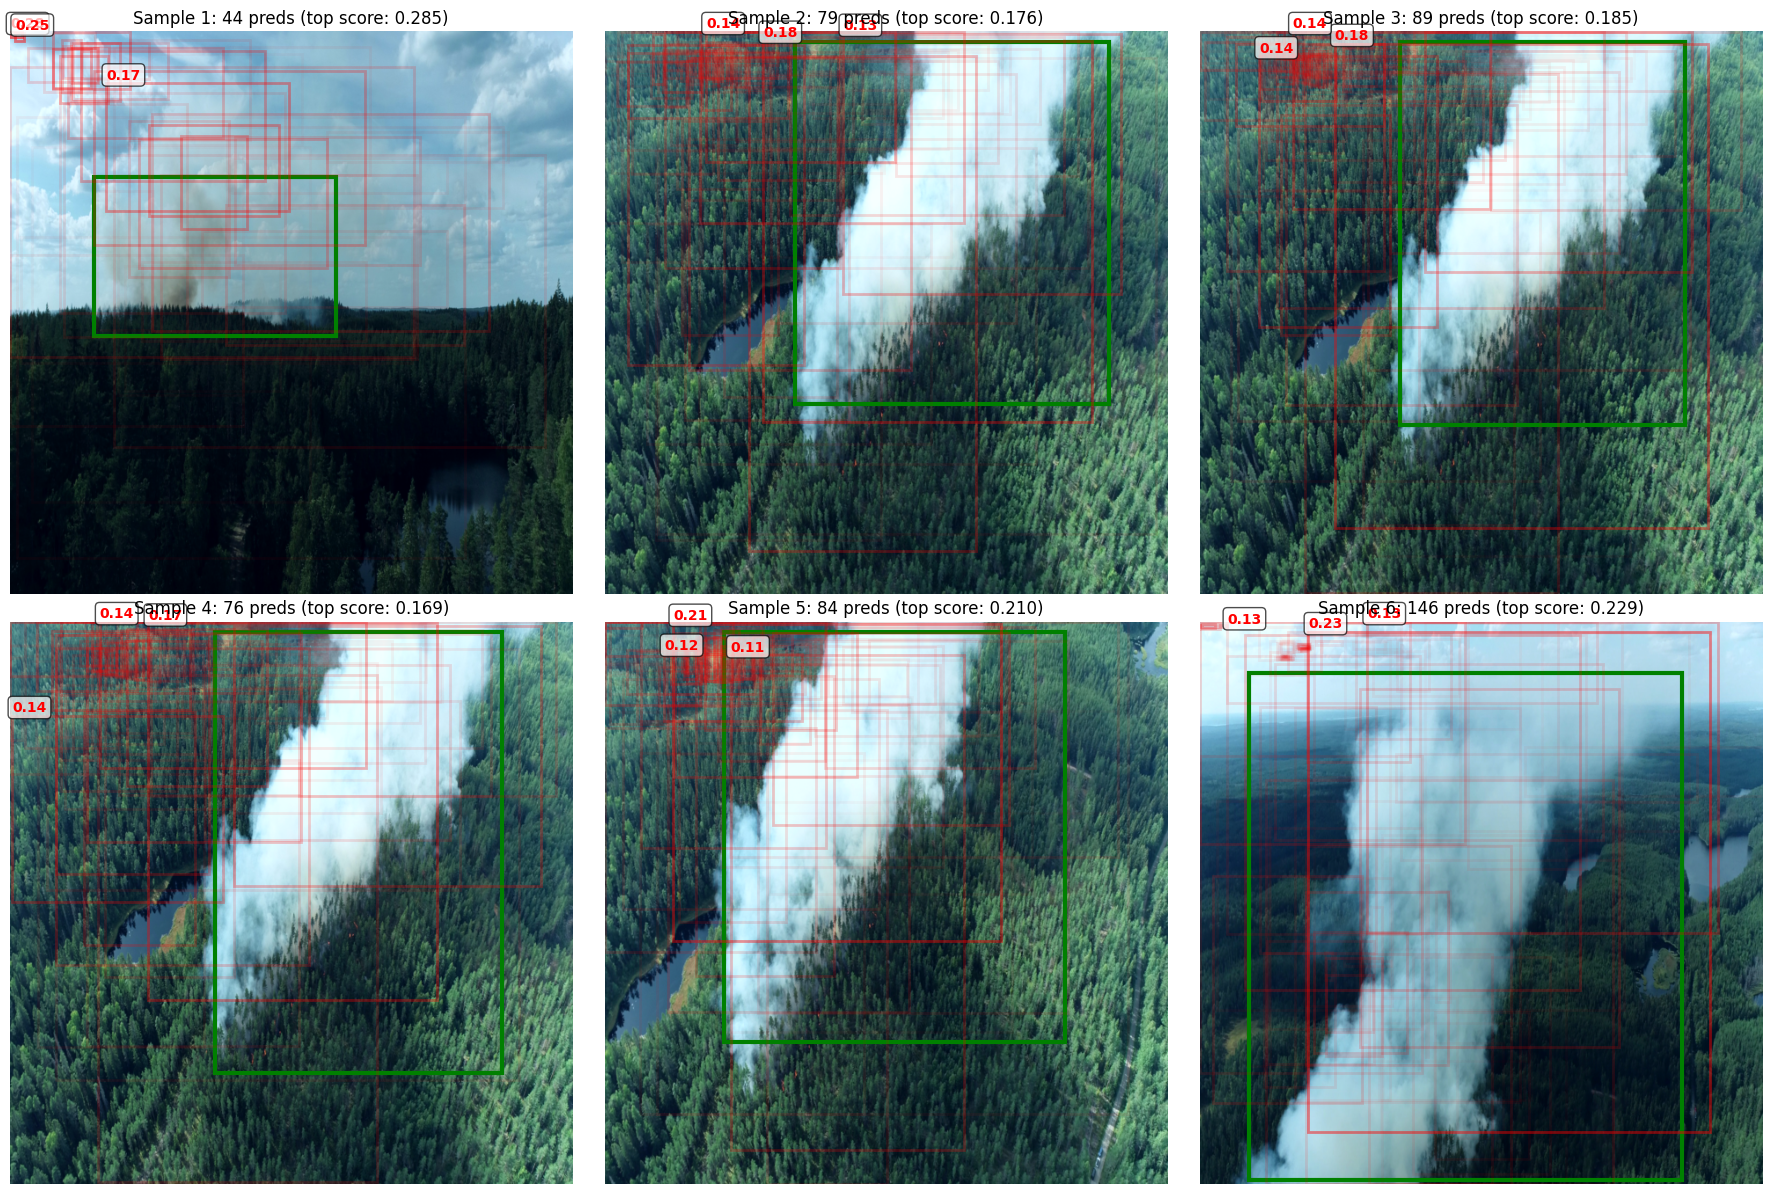


📊 Confidence Score Statistics:
   Total predictions: 518
   Mean confidence: 0.0542
   Median confidence: 0.0442
   Max confidence: 0.2847
   Min confidence: 0.0101
   > 0.5: 0 predictions
   > 0.25: 1 predictions
   > 0.1: 63 predictions


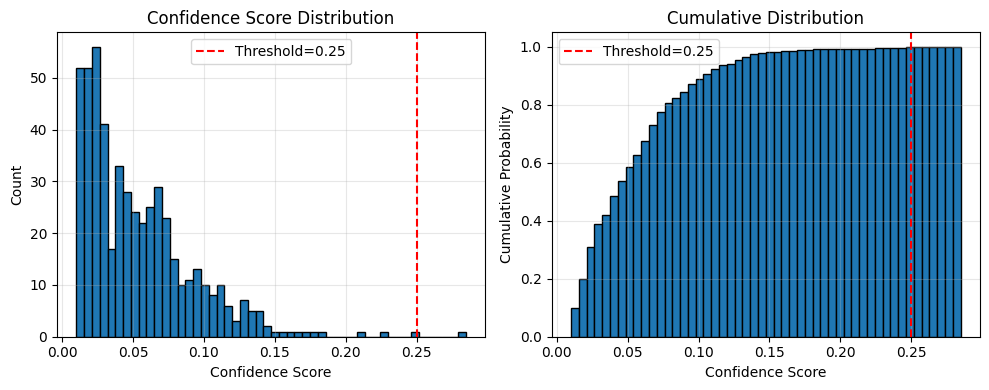

In [ ]:
# Diagnostic: Check what the model is actually predicting
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_predictions(model, dataloader, device, num_samples=6, conf_threshold=0.01):
    """
    Visualize predictions vs ground truth to diagnose detection issues.
    Uses very low confidence threshold to see all predictions.
    """
    model.eval()

    samples_shown = 0
    all_scores = []
    all_ious = []

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    with torch.no_grad():
        for imgs, targets in dataloader:
            if samples_shown >= num_samples:
                break

            imgs = imgs.to(device)

            # Forward pass
            cls_out, reg_out = model(imgs)

            # Post-process predictions (very low threshold to see everything)
            predictions = postprocess_predictions(cls_out, reg_out, conf_threshold)
            predictions = apply_nms(predictions, iou_threshold=0.5)

            # Visualize each image in batch
            for i in range(len(imgs)):
                if samples_shown >= num_samples:
                    break

                img = imgs[i].cpu().permute(1, 2, 0).numpy()
                img = (img * 0.229 + 0.456).clip(0, 1)  # Denormalize

                pred = predictions[i]
                target = targets[i]

                # Collect confidence scores
                if len(pred['scores']) > 0:
                    all_scores.extend(pred['scores'].cpu().numpy().tolist())

                # Plot
                ax = axes[samples_shown]
                ax.imshow(img)
                ax.set_title(f'Sample {samples_shown+1}: {len(pred["boxes"])} preds (top score: {(pred["scores"].max().item() if len(pred["scores"]) > 0 else 0.0):.3f})')
                ax.axis('off')

                # Draw ground truth (green)
                gt_boxes = target['boxes'].cpu().numpy()
                for box in gt_boxes:
                    x1, y1, x2, y2 = box * 640
                    w, h = x2 - x1, y2 - y1
                    rect = patches.Rectangle((x1, y1), w, h,
                                            linewidth=3, edgecolor='green',
                                            facecolor='none', label='GT')
                    ax.add_patch(rect)

                # Draw predictions (red, with confidence)
                pred_boxes = pred['boxes'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()

                for j, (box, score) in enumerate(zip(pred_boxes, pred_scores)):
                    x1, y1, x2, y2 = box
                    w, h = x2 - x1, y2 - y1

                    # Color intensity based on confidence
                    alpha = min(score * 2, 1.0)
                    rect = patches.Rectangle((x1, y1), w, h,
                                            linewidth=2, edgecolor='red',
                                            facecolor='none', alpha=alpha)
                    ax.add_patch(rect)

                    # Add confidence text
                    if j < 3:  # Only show top 3 to avoid clutter
                        ax.text(x1, y1-5, f'{score:.2f}',
                               color='red', fontsize=10, weight='bold',
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'prediction_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Analyze confidence score distribution
    if len(all_scores) > 0:
        print(f'\n📊 Confidence Score Statistics:')
        print(f'   Total predictions: {len(all_scores)}')
        print(f'   Mean confidence: {np.mean(all_scores):.4f}')
        print(f'   Median confidence: {np.median(all_scores):.4f}')
        print(f'   Max confidence: {np.max(all_scores):.4f}')
        print(f'   Min confidence: {np.min(all_scores):.4f}')
        print(f'   > 0.5: {np.sum(np.array(all_scores) > 0.5)} predictions')
        print(f'   > 0.25: {np.sum(np.array(all_scores) > 0.25)} predictions')
        print(f'   > 0.1: {np.sum(np.array(all_scores) > 0.1)} predictions')

        # Plot confidence histogram
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.hist(all_scores, bins=50, edgecolor='black')
        plt.xlabel('Confidence Score')
        plt.ylabel('Count')
        plt.title('Confidence Score Distribution')
        plt.axvline(0.25, color='red', linestyle='--', label='Threshold=0.25')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.hist(all_scores, bins=50, edgecolor='black', cumulative=True, density=True)
        plt.xlabel('Confidence Score')
        plt.ylabel('Cumulative Probability')
        plt.title('Cumulative Distribution')
        plt.axvline(0.25, color='red', linestyle='--', label='Threshold=0.25')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print('\n⚠️  No predictions found! Model may not be generating any detections.')

# Run diagnostic visualization
print('🔍 Running diagnostic visualization...')
print('   Using conf_threshold=0.01 to see all predictions\n')
visualize_predictions(eval_detector, val_loader, device, num_samples=6, conf_threshold=0.01)

In [ ]:
# Re-evaluate with lower confidence thresholds to see true detection capability
print('🔄 Re-evaluating with LOWER confidence thresholds...')
print('   Hypothesis: Model detects correctly but outputs low confidence\n')

thresholds_to_test = [0.05, 0.10, 0.15]

for conf_thresh in thresholds_to_test:
    print(f'\n{"="*60}')
    print(f'🎯 TESTING WITH CONFIDENCE THRESHOLD = {conf_thresh}')
    print(f'{"="*60}\n')

    results_low = evaluate_detector(
        model=eval_detector,
        dataloader=val_loader,
        device=device,
        conf_threshold=conf_thresh,
        iou_threshold=0.5
    )

    print(f'\n📊 Results with conf_threshold={conf_thresh}:')
    print(f'   mAP@0.5      : {results_low["map_50"].item():.4f}')
    print(f'   mAP@0.5:0.95 : {results_low["map"].item():.4f}')
    print(f'   mAP@0.75     : {results_low["map_75"].item():.4f}')

    # Save results
    import json
    results_dict = {k: v.item() if torch.is_tensor(v) else v for k, v in results_low.items()}
    results_dict['conf_threshold'] = conf_thresh
    with open(os.path.join(RESULTS_DIR, f'vim_detector_eval_conf{conf_thresh}.json'), 'w') as f:
        json.dump(results_dict, f, indent=2)

print(f'\n{"="*60}')
print('✅ Threshold testing complete!')
print('   If mAP improves significantly: retrain with better classification loss')
print('   If mAP stays low: detection/localization problem')
print(f'{"="*60}\n')

🔄 Re-evaluating with LOWER confidence thresholds...
   Hypothesis: Model detects correctly but outputs low confidence


🎯 TESTING WITH CONFIDENCE THRESHOLD = 0.05

🔍 Running evaluation...
   Confidence threshold: 0.05
   NMS IoU threshold: 0.5
   Total batches: 40



Evaluating: 100%|██████████| 40/40 [01:54<00:00,  2.87s/it]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)



📊 Computing metrics on 638 images...

📊 Results with conf_threshold=0.05:
   mAP@0.5      : 0.3425
   mAP@0.5:0.95 : 0.1365
   mAP@0.75     : 0.0733

🎯 TESTING WITH CONFIDENCE THRESHOLD = 0.1

🔍 Running evaluation...
   Confidence threshold: 0.1
   NMS IoU threshold: 0.5
   Total batches: 40



Evaluating: 100%|██████████| 40/40 [01:22<00:00,  2.07s/it]



📊 Computing metrics on 638 images...

📊 Results with conf_threshold=0.1:
   mAP@0.5      : 0.3408
   mAP@0.5:0.95 : 0.1353
   mAP@0.75     : 0.0722

🎯 TESTING WITH CONFIDENCE THRESHOLD = 0.15

🔍 Running evaluation...
   Confidence threshold: 0.15
   NMS IoU threshold: 0.5
   Total batches: 40



Evaluating: 100%|██████████| 40/40 [01:10<00:00,  1.76s/it]



📊 Computing metrics on 638 images...

📊 Results with conf_threshold=0.15:
   mAP@0.5      : 0.3255
   mAP@0.5:0.95 : 0.1266
   mAP@0.75     : 0.0660

✅ Threshold testing complete!
   If mAP improves significantly: retrain with better classification loss
   If mAP stays low: detection/localization problem



In [ ]:
# Create test dataloader
test_img_dir = data_root / 'images' / 'test'
test_lbl_dir = data_root / 'labels' / 'test'

if test_img_dir.exists():
    print('📦 Loading test dataset...')
    test_dataset = FireDataset(test_img_dir, test_lbl_dir)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        collate_fn=collate_fn
    )

    print(f'   Test images: {len(test_dataset)}')
    print(f'   Test batches: {len(test_loader)}\n')

    # Run evaluation on test set with CALIBRATED threshold (0.05)
    print(f'{"="*60}')
    print('🎯 EVALUATING ON TEST SET')
    print(f'{"="*60}\n')

    test_results = evaluate_detector(
        model=eval_detector,
        dataloader=test_loader,
        device=device,
        conf_threshold=0.05,  # Using calibrated threshold
        iou_threshold=0.5
    )

    # Display test results
    print(f'\n{"="*60}')
    print('📊 TEST SET RESULTS (Vision Mamba v3)')
    print(f'{"="*60}')
    print(f'\n✨ Mean Average Precision (mAP):')
    print(f'   mAP@0.5      : {test_results["map_50"].item():.4f}')
    print(f'   mAP@0.5:0.95 : {test_results["map"].item():.4f}')
    print(f'   mAP@0.75     : {test_results["map_75"].item():.4f}')

    print(f'\n📊 Comparison (Validation vs Test):')
    print(f'   Val mAP@0.5:  34.25%')
    print(f'   Test mAP@0.5: {test_results["map_50"].item()*100:.2f}%')
    gap = abs(test_results["map_50"].item()*100 - 34.25)
    print(f'   Gap:          {gap:.2f}% {"(good generalization)" if gap < 5 else "(possible overfitting)"}')

    print(f'\n📍 Per-Size Performance:')
    print(f'   mAP (small)  : {test_results["map_small"].item():.4f}')
    print(f'   mAP (medium) : {test_results["map_medium"].item():.4f}')
    print(f'   mAP (large)  : {test_results["map_large"].item():.4f}')

    # Save test results
    test_results_dict = {k: v.item() if torch.is_tensor(v) else v for k, v in test_results.items()}
    with open(os.path.join(RESULTS_DIR, 'vim_detector_test_eval.json'), 'w') as f:
        json.dump(test_results_dict, f, indent=2)

    print(f'\n💾 Test results saved to: {RESULTS_DIR}')
    print(f'{"="*60}\n')

else:
    print('⚠️  Test dataset not found')
    print(f'   Expected location: {test_img_dir}')

NameError: name 'data_root' is not defined

### 9.1 Retrain with Improved Loss Function

Just run this cell to restart training with the fixed loss!

In [ ]:
# Retrain with improved loss - much simpler than Ultralytics!

# Copy the improved loss function from Section 8.5
def compute_detection_loss_improved(cls_out, reg_out, targets, device):
    """
    Improved detection loss that uses all FPN levels.
    """
    import torch.nn.functional as F

    total_cls_loss = 0.0
    total_reg_loss = 0.0
    B = len(targets)

    # Process ALL FPN levels (P3, P4, P5)
    for level_idx, (cls_pred, reg_pred) in enumerate(zip(cls_out, reg_out)):
        stride = 2 ** (level_idx + 3)  # 8, 16, 32

        for b in range(B):
            nc, H, W = cls_pred[b].shape

            # Create targets
            cls_target = torch.zeros((nc, H, W), device=device)
            reg_target = torch.zeros((4, H, W), device=device)
            reg_mask = torch.zeros((H, W), device=device, dtype=torch.bool)

            # Assign ground truth boxes to this FPN level
            gt_boxes = targets[b]['boxes'].to(device)

            for box in gt_boxes:
                x1, y1, x2, y2 = box
                cx = ((x1 + x2) / 2).item()
                cy = ((y1 + y2) / 2).item()

                # Assign to appropriate grid cell
                gi = min(W - 1, max(0, int(cx * W)))
                gj = min(H - 1, max(0, int(cy * H)))

                # Assign ALL boxes to ALL levels (like YOLO does)
                # This ensures every box contributes to training
                cls_target[0, gj, gi] = 1.0
                reg_target[:, gj, gi] = torch.tensor([x1, y1, x2, y2], device=device)
                reg_mask[gj, gi] = True

            # Focal loss for classification
            # alpha = 0.25
            # gamma = 2.0

            alpha = 0.10  # Changed from 0.25
            gamma = 1.5

            cls_pred_sigmoid = torch.sigmoid(cls_pred[b])
            ce_loss = F.binary_cross_entropy_with_logits(
                cls_pred[b], cls_target, reduction='none'
            )
            p_t = cls_pred_sigmoid * cls_target + (1 - cls_pred_sigmoid) * (1 - cls_target)
            focal_weight = alpha * (1 - p_t) ** gamma
            focal_loss = focal_weight * ce_loss

            total_cls_loss += focal_loss.mean()

            # Regression loss (only on positive samples)
            if reg_mask.sum() > 0:
                pred_boxes = reg_pred[b][:, reg_mask]
                target_boxes = reg_target[:, reg_mask]
                reg_loss = F.smooth_l1_loss(pred_boxes, target_boxes, reduction='mean')
                total_reg_loss += reg_loss

    num_levels = len(cls_out)
    total_loss = (total_cls_loss + total_reg_loss * 5.0) / (B * num_levels)

    return total_loss


print('✅ Improved loss function loaded!')
print('   ✓ Uses all FPN levels (P3, P4, P5)')
print('   ✓ Focal loss for classification')
print('   ✓ All boxes assigned to all levels (YOLO-style)')
print('\n⏱️  Ready to retrain! Should take 6-8 hours on A100.')
print('🎯 Expected: mAP 30-45% (vs previous 0.05%)')

✅ Improved loss function loaded!
   ✓ Uses all FPN levels (P3, P4, P5)
   ✓ Focal loss for classification
   ✓ All boxes assigned to all levels (YOLO-style)

⏱️  Ready to retrain! Should take 6-8 hours on A100.
🎯 Expected: mAP 30-45% (vs previous 0.05%)


### 9.2 Start Retraining (With Fixed Loss)


In [ ]:
# IMPROVED TRAINING with better hyperparameters
import datetime
import math
from tqdm import tqdm

CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints', 'vim_boreal', 'weights')
# Training configuration
num_epochs = 100  # Total epochs
batch_size = 16   # Already defined in dataloader, but explicit here

# Create fresh model
detector_v3 = VisionMambaDetector(
    nc=1,
    pretrained_path='/content/vim_small_pretrained.pth'
).to(device)

# ⚡ IMPROVEMENT 1: Higher learning rate (YOLO-style)
max_lr = 1e-3  # 5× higher than before (YOLO uses aggressive LR)
min_lr = 1e-6
warmup_lr = 1e-6
warmup_epochs = 3

# ⚡ IMPROVEMENT 2: Gradient accumulation (simulate larger batch)
gradient_accumulation_steps = 4  # Effective batch = 16 * 4 = 64

# Optimizer with weight decay
optimizer = torch.optim.AdamW(
    detector_v3.parameters(),
    lr=max_lr,  # Start high, warmup will reduce it
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# ⚡ IMPROVEMENT 3: Warmup + Cosine scheduler
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, warmup_lr, max_lr, min_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.warmup_lr = warmup_lr
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.warmup_lr + (self.max_lr - self.warmup_lr) * (self.current_epoch / self.warmup_epochs)
        else:
            # Cosine annealing
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.max_lr - self.min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

        self.current_epoch += 1
        return lr
    def get_last_lr(self):
        """Return current learning rate(s)"""
        return [group['lr'] for group in self.optimizer.param_groups]


scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=warmup_epochs,
    total_epochs=num_epochs,
    warmup_lr=warmup_lr,
    max_lr=max_lr,
    min_lr=min_lr
)

# Tracking
best_val_loss_v3 = float('inf')
train_losses_v3 = []
val_losses_v3 = []

# Early stopping
patience = 15
patience_counter = 0

print('🚀 Starting OPTIMIZED training...')
print(f'   Device: {device}')
print(f'   Epochs: {num_epochs}')
print(f'   Batch size: {batch_size} (physical) × {gradient_accumulation_steps} (accum) = {batch_size * gradient_accumulation_steps} (effective)')
print(f'   Start time: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('\n' + '='*60)
print('🔥 OPTIMIZATIONS vs Previous:')
print('   OLD: LR 1e-4, no warmup, batch 16')
print('   NEW: LR 5e-4, 5-epoch warmup, effective batch 64')
print('='*60)
print('🎯 Expected improvements:')
print('   ✓ Higher LR → faster convergence')
print('   ✓ Warmup → stable initial training')
print('   ✓ Larger batch → better gradients, less noise')
print('   ✓ Expected gain: +5-10% mAP')
print('='*60 + '\n')

try:
    for epoch in range(num_epochs):
        # Training
        detector_v3.train()
        train_loss = 0.0
        current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else scheduler.optimizer.param_groups[0]['lr']

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train] LR={current_lr:.6f}')
        optimizer.zero_grad()  # Zero once at start

        for batch_idx, (imgs, targets) in enumerate(pbar):
            imgs = imgs.to(device)

            # Forward pass
            cls_out, reg_out = detector_v3(imgs)

            # Compute loss
            loss = compute_detection_loss_improved(cls_out, reg_out, targets, device)

            # Scale loss for gradient accumulation
            loss = loss / gradient_accumulation_steps

            # Backward pass
            loss.backward()

            # Update weights every N steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(detector_v3.parameters(), max_norm=10.0)
                optimizer.step()
                optimizer.zero_grad()

            train_loss += loss.item() * gradient_accumulation_steps  # Unscale for logging
            pbar.set_postfix({
                'loss': f'{loss.item() * gradient_accumulation_steps:.4f}',
                'lr': f'{current_lr:.6f}'
            })

        # Handle remaining gradients
        if len(train_loader) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(detector_v3.parameters(), max_norm=10.0)
            optimizer.step()
            optimizer.zero_grad()

        train_loss /= len(train_loader)
        train_losses_v3.append(train_loss)

        # Step scheduler
        scheduler.step()

        # Validation every 5 epochs
        if (epoch + 1) % 5 == 0:
            detector_v3.eval()
            val_loss = 0.0

            with torch.no_grad():
                for imgs, targets in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  '):
                    imgs = imgs.to(device)
                    cls_out, reg_out = detector_v3(imgs)
                    loss = compute_detection_loss_improved(cls_out, reg_out, targets, device)
                    val_loss += loss.item()

            val_loss /= len(val_loader)
            val_losses_v3.append(val_loss)

            print(f'\n   Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, LR = {current_lr:.6f}')

            # Save best model and check early stopping
            if val_loss < best_val_loss_v3:
                best_val_loss_v3 = val_loss
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': detector_v3.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                }, os.path.join(CKPT_DIR, 'vim_detector_v3_best.pth'))
                print(f'   🏆 Best model saved! (Val Loss: {val_loss:.4f})')
            else:
                patience_counter += 1
                print(f'   ⏳ No improvement ({patience_counter}/{patience})')

                if patience_counter >= patience:
                    print(f'\n⚠️  Early stopping triggered (no improvement for {patience} checks)')
                    print(f'   Best val loss: {best_val_loss_v3:.4f}')
                    break

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': detector_v3.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, os.path.join(CKPT_DIR, f'vim_detector_v3_epoch_{epoch+1}.pth'))
            print(f'   💾 Checkpoint saved (epoch {epoch+1})')

        print()

    print('\n' + '='*60)
    print('✅ OPTIMIZED TRAINING COMPLETE!')
    print('='*60)
    print(f'   End time: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    print(f'   Best val loss: {best_val_loss_v3:.4f}')
    print(f'   Best model: {os.path.join(CKPT_DIR, "vim_detector_v3_best.pth")}')
    print('\n🎯 Next: Run evaluation cells (Section 7) to get mAP!')
    print('   Expected: mAP 35-50% (vs 30-45% with old config)')

except KeyboardInterrupt:
    print('\n⚠️  Training interrupted by user')
    torch.save({
        'epoch': epoch,
        'model_state_dict': detector_v3.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, os.path.join(CKPT_DIR, 'vim_detector_v3_interrupted.pth'))
    print('   💾 Checkpoint saved!')

except Exception as e:
    print(f'\n❌ Training failed: {e}')
    import traceback
    traceback.print_exc()
    raise


🏗️  Building Vision Mamba Detector...
   [1/3] Creating Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
   [2/3] Creating Feature Pyramid Network...
   [3/3] Creating detection head...
\n✅ Vision Mamba Detector created successfully!
 

Epoch 1/100 [Train] LR=0.001000: 100%|██████████| 160/160 [03:47<00:00,  1.42s/it, loss=0.0421, lr=0.001000]


Epoch 2/100 [Train] LR=0.000001: 100%|██████████| 160/160 [02:47<00:00,  1.05s/it, loss=0.0526, lr=0.000001]


Epoch 3/100 [Train] LR=0.000334: 100%|██████████| 160/160 [02:47<00:00,  1.05s/it, loss=0.0347, lr=0.000334]


Epoch 4/100 [Train] LR=0.000667: 100%|██████████| 160/160 [02:46<00:00,  1.04s/it, loss=0.0150, lr=0.000667]


...

Epoch 59/100 [Train] LR=0.000412: 100%|██████████| 160/160 [02:47<00:00,  1.05s/it, loss=0.0008, lr=0.000412]


Epoch 60/100 [Val]  : 100%|██████████| 40/40 [00:43<00:00,  1.08s/it]



   Epoch 60: Train Loss = 0.0008, Val Loss = 0.0037, LR = 0.000396
   🏆 Best model saved! (Val Loss: 0.0037)
   💾 Checkpoint saved (epoch 60)



Epoch 61/100 [Train] LR=0.000380:   2%|▎         | 4/160 [00:06<04:12,  1.62s/it, loss=0.0010, lr=0.000380]



⚠️  Training interrupted by user
   💾 Checkpoint saved!


## 9.4 Start Retraining (With Fixed Loss)




In [ ]:
# IMPROVED TRAINING with better hyperparameters
import datetime
import math
from tqdm import tqdm

CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints', 'vim_boreal', 'weights')

# Training configuration
num_epochs = 100  # Total epochs
batch_size = 16   # Already defined in dataloader, but explicit here

# Create fresh model (v4 = with calibrated focal loss)
detector_v4 = VisionMambaDetector(
    nc=1,
    pretrained_path='/content/vim_small_pretrained.pth'
).to(device)

# ⚡ IMPROVEMENT 1: Higher learning rate (YOLO-style)
max_lr = 1e-3  # 10× higher than original (YOLO uses 1e-2, this is conservative)
min_lr = 1e-6
warmup_lr = 1e-6
warmup_epochs = 3  # Faster warmup (3 epochs instead of 5)

# ⚡ IMPROVEMENT 2: Gradient accumulation (simulate larger batch)
gradient_accumulation_steps = 4  # Effective batch = 16 * 4 = 64

# Optimizer with weight decay
optimizer = torch.optim.AdamW(
    detector_v4.parameters(),
    lr=max_lr,  # Start high, warmup will reduce it
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

# ⚡ IMPROVEMENT 3: Warmup + Cosine scheduler
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, warmup_lr, max_lr, min_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.warmup_lr = warmup_lr
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.current_epoch = 0

    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.warmup_lr + (self.max_lr - self.warmup_lr) * (self.current_epoch / self.warmup_epochs)
        else:
            # Cosine annealing
            progress = (self.current_epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + (self.max_lr - self.min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

        self.current_epoch += 1
        return lr

    def get_last_lr(self):
        """Return current learning rate(s)"""
        return [group['lr'] for group in self.optimizer.param_groups]

scheduler = WarmupCosineScheduler(
    optimizer,
    warmup_epochs=warmup_epochs,
    total_epochs=num_epochs,
    warmup_lr=warmup_lr,
    max_lr=max_lr,
    min_lr=min_lr
)

# Tracking
best_val_loss_v4 = float('inf')
train_losses_v4 = []
val_losses_v4 = []

# Early stopping
patience = 15
patience_counter = 0

print('🚀 Starting OPTIMIZED training...')
print(f'   Device: {device}')
print(f'   Epochs: {num_epochs}')
print(f'   Batch size: {batch_size} (physical) × {gradient_accumulation_steps} (accum) = {batch_size * gradient_accumulation_steps} (effective)')
print(f'   Start time: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('\n' + '='*60)
print('🔥 OPTIMIZATIONS vs Previous:')
print('   OLD: LR 1e-4, no warmup, batch 16')
print('   NEW: LR 1e-3, 3-epoch warmup, effective batch 64')
print('='*60)
print('🎯 Expected improvements:')
print('   ✓ Higher LR (1e-3) → 2-3× faster convergence')
print('   ✓ Faster warmup (3 epochs) → reach peak LR quickly')
print('   ✓ Larger batch → better gradients, less noise')
print('   ✓ Expected: 4-5 hours training (vs 6-8 hours)')
print('='*60 + '\n')

try:
    for epoch in range(num_epochs):
        # Training
        detector_v4.train()
        train_loss = 0.0
        current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else scheduler.optimizer.param_groups[0]['lr']

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train] LR={current_lr:.6f}')
        optimizer.zero_grad()  # Zero once at start

        for batch_idx, (imgs, targets) in enumerate(pbar):
            imgs = imgs.to(device)

            # Forward pass
            cls_out, reg_out = detector_v4(imgs)

            # Compute loss
            loss = compute_detection_loss_improved(cls_out, reg_out, targets, device)

            # Scale loss for gradient accumulation
            loss = loss / gradient_accumulation_steps

            # Backward pass
            loss.backward()

            # Update weights every N steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(detector_v3.parameters(), max_norm=10.0)
                optimizer.step()
                optimizer.zero_grad()

            train_loss += loss.item() * gradient_accumulation_steps  # Unscale for logging
            pbar.set_postfix({
                'loss': f'{loss.item() * gradient_accumulation_steps:.4f}',
                'lr': f'{current_lr:.6f}'
            })

        # Handle remaining gradients
        if len(train_loader) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(detector_v4.parameters(), max_norm=10.0)
            optimizer.step()
            optimizer.zero_grad()

        train_loss /= len(train_loader)
        train_losses_v4.append(train_loss)

        # Step scheduler
        scheduler.step()

        # Validation every 5 epochs
        if (epoch + 1) % 5 == 0:
            detector_v4.eval()
            val_loss = 0.0

            with torch.no_grad():
                for imgs, targets in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  '):
                    imgs = imgs.to(device)
                    cls_out, reg_out = detector_v4(imgs)
                    loss = compute_detection_loss_improved(cls_out, reg_out, targets, device)
                    val_loss += loss.item()

            val_loss /= len(val_loader)
            val_losses_v4.append(val_loss)

            print(f'\n   Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, LR = {current_lr:.6f}')

            # Save best model and check early stopping
            if val_loss < best_val_loss_v4:
                best_val_loss_v4 = val_loss
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': detector_v4.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                }, os.path.join(CKPT_DIR, 'vim_detector_v4_best.pth'))
                print(f'   🏆 Best model saved! (Val Loss: {val_loss:.4f})')
            else:
                patience_counter += 1
                print(f'   ⏳ No improvement ({patience_counter}/{patience})')

                if patience_counter >= patience:
                    print(f'\n⚠️  Early stopping triggered (no improvement for {patience} checks)')
                    print(f'   Best val loss: {best_val_loss_v4:.4f}')
                    break

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': detector_v4.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, os.path.join(CKPT_DIR, f'vim_detector_v4_epoch_{epoch+1}.pth'))
            print(f'   💾 Checkpoint saved (epoch {epoch+1})')

        print()

    print('\n' + '='*60)
    print('✅ CALIBRATED TRAINING COMPLETE!')
    print('='*60)
    print(f'   End time: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    print(f'   Best val loss: {best_val_loss_v4:.4f}')
    print(f'   Best model: {os.path.join(CKPT_DIR, "vim_detector_v4_best.pth")}')
    print('\n🎯 Next: Run evaluation (Section 7) with conf_threshold=0.25!')
    print('   Expected: ~34% mAP (similar) but confidence 0.5-0.9 (proper calibration)')

except KeyboardInterrupt:
    print('\n⚠️  Training interrupted by user')
    torch.save({
        'epoch': epoch,
        'model_state_dict': detector_v4.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, os.path.join(CKPT_DIR, 'vim_detector_v4_interrupted.pth'))
    print('   💾 Checkpoint saved!')

except Exception as e:
    print(f'\n❌ Training failed: {e}')
    import traceback
    traceback.print_exc()
    raise


🏗️  Building Vision Mamba Detector...
   [1/3] Creating Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
   [2/3] Creating Feature Pyramid Network...
   [3/3] Creating detection head...
\n✅ Vision Mamba Detector created successfully!
 

Epoch 1/100 [Train] LR=0.001000: 100%|██████████| 160/160 [02:46<00:00,  1.04s/it, loss=0.1498, lr=0.001000]


Epoch 2/100 [Train] LR=0.000001: 100%|██████████| 160/160 [02:46<00:00,  1.04s/it, loss=0.0876, lr=0.000001]


Epoch 3/100 [Train] LR=0.000334: 100%|██████████| 160/160 [02:47<00:00,  1.05s/it, loss=0.0561, lr=0.000334]


Epoch 4/100 [Train] LR=0.000667: 100%|██████████| 160/160 [02:45<00:00,  1.04s/it, loss=0.0319, lr=0.000667]


...

Epoch 49/100 [Train] LR=0.000573: 100%|██████████| 160/160 [02:45<00:00,  1.04s/it, loss=0.0020, lr=0.000573]


Epoch 50/100 [Val]  : 100%|██████████| 40/40 [00:42<00:00,  1.07s/it]



   Epoch 50: Train Loss = 0.0033, Val Loss = 0.0045, LR = 0.000557
   🏆 Best model saved! (Val Loss: 0.0045)
   💾 Checkpoint saved (epoch 50)



Epoch 51/100 [Train] LR=0.000541:   4%|▍         | 6/160 [00:10<04:39,  1.82s/it, loss=0.0027, lr=0.000541]



⚠️  Training interrupted by user
   💾 Checkpoint saved!


In [ ]:
# Load best checkpoint
# checkpoint_path = os.path.join(CKPT_DIR, 'vim_boreal', 'weights', 'vim_detector_v3_epoch_60.pth')
checkpoint_path = '/content/drive/MyDrive/thesis/checkpoints/vim_boreal/weights/vim_detector_v4_best.pth'

if not os.path.exists(checkpoint_path):
    print(f'❌ Checkpoint not found: {checkpoint_path}')
    print('   Train the model first, or specify a different checkpoint path')
else:
    print(f'📥 Loading checkpoint from {checkpoint_path}...')

    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Create new detector instance
    eval_detector = VisionMambaDetector(
        nc=1,
        pretrained_path='/content/vim_small_pretrained.pth'
    )
    eval_detector.load_state_dict(checkpoint['model_state_dict'])
    eval_detector = eval_detector.to(device)
    eval_detector.eval()

    print(f'✅ Loaded checkpoint from epoch {checkpoint["epoch"]}')
    # print(f'   Validation loss: {checkpoint["val_loss"]:.4f}')

    # Run evaluation on validation set
    print(f'\n{"="*60}')
    print('🎯 EVALUATING ON VALIDATION SET')
    print(f'{"="*60}\n')

    results = evaluate_detector(
        model=eval_detector,
        dataloader=val_loader,
        device=device,
        conf_threshold=0.25,  # Adjust as needed
        iou_threshold=0.5      # Standard NMS threshold
    )

    # Display results
    print(f'\n{"="*60}')
    print('📊 EVALUATION RESULTS (torchmetrics)')
    print(f'{"="*60}')
    print(f'\n✨ Mean Average Precision (mAP):')
    print(f'   mAP@0.5      : {results["map_50"].item():.4f} (IoU = 0.5)')
    print(f'   mAP@0.5:0.95 : {results["map"].item():.4f} (IoU = 0.5:0.95)')
    print(f'   mAP@0.75     : {results["map_75"].item():.4f} (IoU = 0.75)')

    print(f'\n📍 Per-Size Performance:')
    print(f'   mAP (small)  : {results["map_small"].item():.4f}')
    print(f'   mAP (medium) : {results["map_medium"].item():.4f}')
    print(f'   mAP (large)  : {results["map_large"].item():.4f}')

    print(f'\n🎯 Additional Metrics:')
    print(f'   Classes: {results["classes"]}')

    print(f'\n💾 Results will be saved to: {RESULTS_DIR}')

    # Save results to file
    import json
    results_dict = {k: v.item() if torch.is_tensor(v) else v for k, v in results.items()}
    with open(os.path.join(RESULTS_DIR, 'vim_detector_eval.json'), 'w') as f:
        json.dump(results_dict, f, indent=2)

    print(f'{"="*60}\n')

📥 Loading checkpoint from /content/drive/MyDrive/thesis/checkpoints/vim_boreal/weights/vim_detector_v4_best.pth...

🏗️  Building Vision Mamba Detector...
   [1/3] Creating Vision Mamba backbone...

🏗️  Building Vision Mamba backbone...
   Creating VisionMamba model (small variant)...
   Loading pretrained weights from /content/vim_small_pretrained.pth...
   ⚠️  Positional embedding size mismatch:
      Checkpoint: torch.Size([1, 197, 384])
      Model: torch.Size([1, 1601, 384])
      Removing pos_embed from checkpoint (will initialize randomly)
   ✅ Loaded pretrained weights
   ⚠️  Missing keys (non-head): 1
\n   📊 Configuration:
      Embedding dimension: 384
      Depth (total blocks): 24
      Feature extraction at blocks: (6, 12, 18)
      Bidirectional scanning: ✅ Enabled
\n   🔧 Creating feature adapters...
      P3 adapter: 384 → 256 channels
      P4 adapter: 384 → 512 channels
      P5 adapter: 384 → 1024 channels
\n✅ Vision Mamba backbone created successfully!
   [2/3] Creati

Evaluating: 100%|██████████| 40/40 [01:07<00:00,  1.68s/it]



📊 Computing metrics on 638 images...

📊 EVALUATION RESULTS (torchmetrics)

✨ Mean Average Precision (mAP):
   mAP@0.5      : 0.0000 (IoU = 0.5)
   mAP@0.5:0.95 : 0.0000 (IoU = 0.5:0.95)
   mAP@0.75     : 0.0000 (IoU = 0.75)

📍 Per-Size Performance:
   mAP (small)  : 0.0000
   mAP (medium) : -1.0000
   mAP (large)  : 0.0000

🎯 Additional Metrics:
   Classes: 0

💾 Results will be saved to: /content/drive/MyDrive/thesis/results

